In [1]:
# Imports
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import zfit
import xgboost
from sklearn.metrics import roc_curve
from scipy.stats import norm


c:\Users\cissi\anaconda3\envs\tf\Lib\site-packages\zfit\__init__.py:93: UserWarning: TensorFlow warnings are by default suppressed by zfit. In order to show them, set the environment variable ZFIT_DISABLE_TF_WARNINGS=0. In order to suppress the TensorFlow warnings AND this warning, set ZFIT_DISABLE_TF_WARNINGS=1.
  warnings.warn(


In [2]:
pink = '#E8B9CD'
blue = '#A4B2D6'
purple = '#BAA4B6'
grey = "#36393A"
imperial_blue = '#0000CD'
imperial_pink = '#C71585'

# Task 1

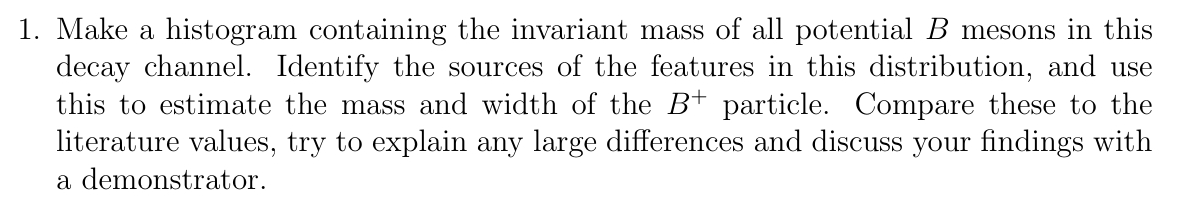

In [3]:
# Load the 2011 dataset
with open(r"C:\Users\cissi\OneDrive - Imperial College London\Y3Lab\C1_notebooks\C1\McCann, Michael A's files - 3rd Year Labs - Particle Physics Data\LHCb\dataset_2011.pkl", 'rb') as infile:
  data_2011 = pickle.load(infile)

In [4]:
# Load the 2012 dataset
with open(r"C:\Users\cissi\OneDrive - Imperial College London\Y3Lab\C1_notebooks\C1\McCann, Michael A's files - 3rd Year Labs - Particle Physics Data\LHCb\dataset_2012_MagnetDown.pkl", 'rb') as infile:
  data_2012_down = pickle.load(infile)

with open(r"C:\Users\cissi\OneDrive - Imperial College London\Y3Lab\C1_notebooks\C1\McCann, Michael A's files - 3rd Year Labs - Particle Physics Data\LHCb\dataset_2012_MagnetUp.pkl", 'rb') as infile:
  data_2012_up = pickle.load(infile)

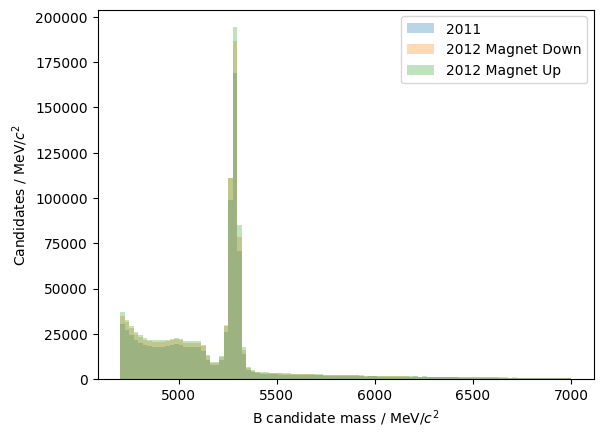

In [5]:
alpha = 0.3
plt.hist(data_2011['B invariant mass'], bins=100, alpha = alpha, label='2011')
plt.hist(data_2012_down['B invariant mass'], bins=100, alpha = alpha, label='2012 Magnet Down')
plt.hist(data_2012_up['B invariant mass'], bins=100, alpha = alpha, label='2012 Magnet Up')
plt.xlabel(r'B candidate mass / MeV/$c^2$')
plt.ylabel(r'Candidates / MeV/$c^2$')
plt.legend()
plt.show()

All 3 datasets show $\approx$ same peak so we can combine them to analyse the datasets together

In [6]:
#We're going to do an extended unbinned maximum likelihood fit. First we need
#to set up the PDF that we want to fit to our data above

#The data in this example is a very simple gaussian peak on an exponential
#background. Whether your data looks like this is task to investigate

#First we need to define our indepednent variable and its range

mass = zfit.Space('B invariant mass', (5000, 6000))

#Next we define the model parameters (an initial guess and their allowed ranges)
#For the signal we've got a gaussian, so need a mean and sigma, and of course a
#yield (or number of signal events)

mean  = zfit.Parameter('mean', 5250, 5000, 6000)
sigma = zfit.Parameter('sigma', 20,    5,  100)
signalYield = zfit.Parameter('signalYield', 5000, 0, 1000000)

#Now to define the signal model
signalPDF = zfit.pdf.Gauss(obs=mass, mu=mean, sigma=sigma, extended=signalYield)


#We're using an exponential for the background model, so we have an exponent
#parameter (and a yield)
exponent  = zfit.Parameter('exponent', -0.01, -1e-1, -1e-6)
backgroundYield = zfit.Parameter('backgroundYield', 5000, 0, 1000000)

#define the background model
backgroundPDF = zfit.pdf.Exponential(obs=mass, lam=exponent, extended=backgroundYield)

#The total pdf to fit to the data is the sum of the signal and background
totalPDF = zfit.pdf.SumPDF(pdfs=[signalPDF, backgroundPDF])


In [7]:
#We need to convert this dataset into something the zfit package can use
all_data = pd.concat([data_2011, data_2012_down, data_2012_up], ignore_index=True)
zdata = zfit.Data.from_pandas(all_data, mass)

In [8]:
#Now we can create the likelihood that we will maximise. [We will actually
#create the negative of the log of the likelihood (NLL), and minimise that]

nll = zfit.loss.ExtendedUnbinnedNLL(model=totalPDF, data=zdata)

#We then ask the minimiser (Minuit here) find the parameters that minimise the
#liklehood
minimizer = zfit.minimize.Minuit()
result = minimizer.minimize(nll)

#To compute the uncertainty on the parameters we can use Hesse. This estimates
#the uncertainties from the second gradient at the minimum. This is good when
#the likelihood is nicely parabolic, i.e. in the asymptotic limit. The coverage
#of Hesse should always be checked. There are alternatives, e.g. Minos that
#can cope with slightly asymmetric minima, but again the coverage should always
#be checked.
param_hesse = result.hesse()

#print the result, and also explicitly access the result information. This is
#important as the minimiser will always complete, but that doesn't mean it has
#converged or that it has found a sensible minimum. Minuit has a few parameters
#to tweak how it behaves, the strategy and tolerance are usually the most
#important, but sometimes it is necessary to kick the minimiser out of e.g. a
#local minimum.
print(result)
print(f"Function minimum: {result.fmin}")
print(f"Converged: {result.converged}")
print(f"Valid: {result.valid}")


FitResult of
<ExtendedUnbinnedNLL model=[<zfit.<class 'zfit.models.functor.SumPDF'>  params=[Composed_autoparam_1, Composed_autoparam_2]] data=[<zfit.Data: Data obs=('B invariant mass',) shape=(1936635, 1)>] constraints=[]> 
with
<Minuit Minuit, tol=0.001>

╒═════════╤═════════════╤══════════════════╤═════════╤══════════════════════════════╕
│  valid  │  converged  │  param at limit  │   edm   │   approx. fmin (full | opt.) │
╞═════════╪═════════════╪══════════════════╪═════════╪══════════════════════════════╡
│  False  │    True     │       True       │ 3.2e-05 │  11222333.46 | -1.010885e+07 │
╘═════════╧═════════════╧══════════════════╧═════════╧══════════════════════════════╛

Parameters
name               value  (rounded)        hesse    at limit
---------------  ------------------  -----------  ----------
signalYield                   1e+06  +/- 0.00088        True
backgroundYield              843357  +/-   1e+03       False
mean                        5283.62  +/-    0.02       F

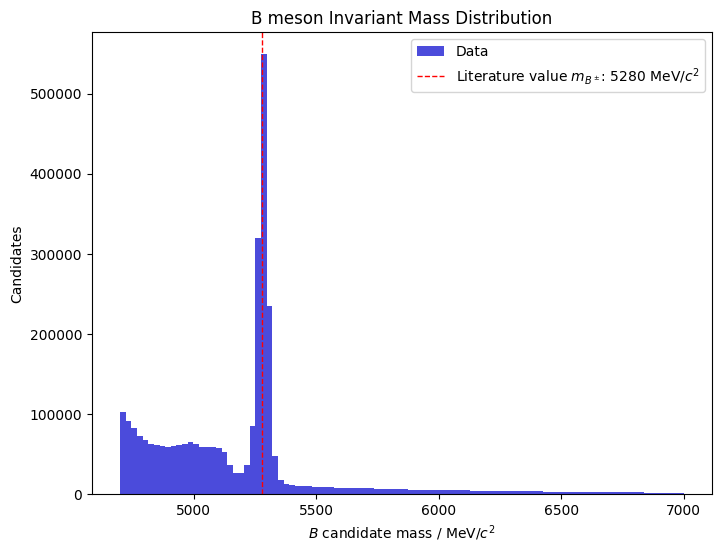

In [9]:
import matplotlib.pyplot as plt

# 1. Set style and figure
plt.style.use('default')
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Plot histogram 
# Note: imperial_blue must be defined as a hex or string (e.g., '#003E7E')
# Increased alpha to 0.5 so you can actually see the data
plt.hist(all_data['B invariant mass'], bins=100, alpha=0.7, 
         color=imperial_blue, label='Data')

# 3. Add vertical line for B mass peak
plt.axvline(x=5280, color='r', linestyle='--', linewidth=1, 
            label=r'Literature value $m_{B^\pm}$: 5280 MeV/$c^2$')

# 4. Labeling
plt.xlabel(r'$B$ candidate mass / MeV/$c^2$')
plt.ylabel(r'Candidates')
plt.title('B meson Invariant Mass Distribution')

plt.legend()

# 5. Make the plot background transparent
# This removes the white "box" behind the chart
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)

# 6. Save with transparency
plt.savefig('B_mass_transparent.png', transparent=True, bbox_inches='tight', dpi=300)
plt.show()

Mean: 5283.62  +/-   0.02
Sigma: 18.3068  +/-   0.017

# Task 2

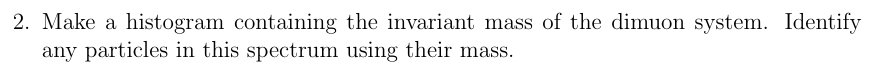

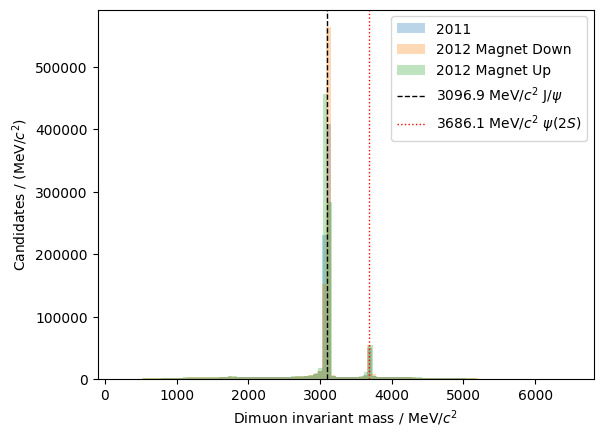

In [10]:
alpha = 0.3
plt.hist(data_2011['dimuon-system invariant mass'], bins=100, alpha = alpha, label='2011')
plt.hist(data_2012_down['dimuon-system invariant mass'], bins=100, alpha = alpha, label='2012 Magnet Down')
plt.hist(data_2012_up['dimuon-system invariant mass'], bins=100, alpha = alpha, label='2012 Magnet Up')

plt.axvline(x=3096.9, color='k', linestyle='--', linewidth=1, label=r'3096.9 MeV/$c^2$ J/$\psi$')
plt.axvline(x=3686.1, color='r', linestyle=':', linewidth=1, label=r'3686.1 MeV/$c^2$ $\psi(2S)$')

plt.xlabel(r'Dimuon invariant mass / MeV/$c^2$')
plt.ylabel(r'Candidates / (MeV/$c^2)$')
plt.legend()
plt.show()

- $J/\psi$ Meson: This will be the most prominent peak in your spectrum, located at approximately $3097$ MeV/$c^2$ . This is a charm-anticharm ($c\bar{c}$) bound state.
- $\psi(2S)$ Meson: You may see a second, smaller peak at a higher mass of approximately $3686$ MeV/$c^2$, which is the first excited state of the charmonium system.

In [11]:
# 1. Define the range to include both peaks
# We'll focus on the region between 2800 and 4200 MeV
dim_mass = zfit.Space('dimuon-system invariant mass', limits=(2800, 4200))

# 2. Parameters for the J/psi peak (the large one)
mu_jpsi    = zfit.Parameter('mu_jpsi', 3097, 3050, 3150)
sigma_jpsi = zfit.Parameter('sigma_jpsi', 15, 5, 50)
yield_jpsi = zfit.Parameter('yield_jpsi', 1000000, 0, 5000000)

signal_jpsi = zfit.pdf.Gauss(obs=dim_mass, mu=mu_jpsi, sigma=sigma_jpsi, extended=yield_jpsi)

# 3. Parameters for the psi(2S) peak (the smaller one)
mu_psi2s    = zfit.Parameter('mu_psi2s', 3686, 3650, 3750)
sigma_psi2s = zfit.Parameter('sigma_psi2s', 15, 5, 50)
yield_psi2s = zfit.Parameter('yield_psi2s', 50000, 0, 1000000)

signal_psi2s = zfit.pdf.Gauss(obs=dim_mass, mu=mu_psi2s, sigma=sigma_psi2s, extended=yield_psi2s)

# 4. Background (Exponential)
exponent    = zfit.Parameter('exponent', -0.001, -0.1, 0.0)
yield_bg    = zfit.Parameter('yield_bg', 100000, 0, 2000000)

background  = zfit.pdf.Exponential(obs=dim_mass, lam=exponent, extended=yield_bg)

# 5. Combine everything into one model
total_model = zfit.pdf.SumPDF(pdfs=[signal_jpsi, signal_psi2s, background])

# 6. Load data and run the fit
# Ensure 'all_data' is your pandas DataFrame and the column name matches your logic
zdata = zfit.Data.from_pandas(all_data, dim_mass) 
nll = zfit.loss.ExtendedUnbinnedNLL(model=total_model, data=zdata)

minimizer = zfit.minimize.Minuit()
result = minimizer.minimize(nll)

# Calculate errors
result.hesse()

print(result)

FitResult of
<ExtendedUnbinnedNLL model=[<zfit.<class 'zfit.models.functor.SumPDF'>  params=[Composed_autoparam_4, Composed_autoparam_5, Composed_autoparam_6]] data=[<zfit.Data: Data obs=('dimuon-system invariant mass',) shape=(2540406, 1)>] constraints=[]> 
with
<Minuit Minuit, tol=0.001>

╒═════════╤═════════════╤══════════════════╤═════════╤══════════════════════════════╕
│  valid  │  converged  │  param at limit  │   edm   │   approx. fmin (full | opt.) │
╞═════════╪═════════════╪══════════════════╪═════════╪══════════════════════════════╡
│  True   │    True     │      False       │ 0.00055 │      12932990.46 | -683687.2 │
╘═════════╧═════════════╧══════════════════╧═════════╧══════════════════════════════╛

Parameters
name           value  (rounded)        hesse    at limit
-----------  ------------------  -----------  ----------
yield_jpsi          2.02892e+06  +/- 1.4e+03       False
yield_psi2s              162947  +/- 4.3e+02       False
yield_bg                 348518  +/- 6

- $J/\psi$ Meson:
    - mean: 3099.34  +/-   0.011
    - sigma: 14.9641  +/-  0.0091
- $\psi(2S)$ Meson:
    - mean: 3689.36  +/-   0.047
    - sigma: 16.4943  +/-   0.041

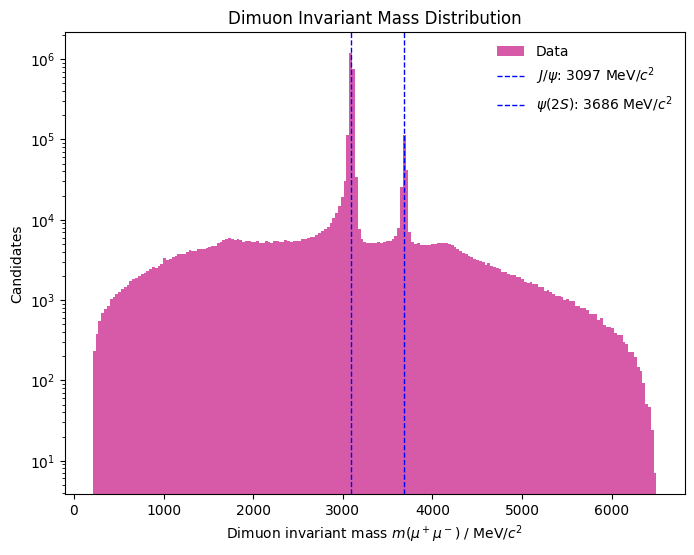

In [12]:
import matplotlib.pyplot as plt

# 1. Set style and figure
plt.style.use('default')
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Plotting - increased bins for resonance detail
plt.hist(all_data['dimuon-system invariant mass'], bins=200, alpha=0.7, 
         color=imperial_pink, label='Data')

# 3. Physics Markers
plt.axvline(x=3097, color='blue', linestyle='--', linewidth=1, label=r'$J/\psi$: 3097 MeV/$c^2$')
plt.axvline(x=3686, color='blue', linestyle='--', linewidth=1, label=r'$\psi(2S)$: 3686 MeV/$c^2$')

# 4. Corrected Labels
plt.xlabel(r'Dimuon invariant mass $m(\mu^+\mu^-)$ / MeV/$c^2$')
plt.ylabel(r'Candidates')
plt.title('Dimuon Invariant Mass Distribution')
plt.yscale('log') # Switch to log scale to see the Psi(2S)
plt.legend(frameon=False)

# 5. Transparency settings
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)

# 6. Save
plt.savefig('dimuon_mass_transparent.png', transparent=True, bbox_inches='tight', dpi=300)
plt.show()

# Task 3

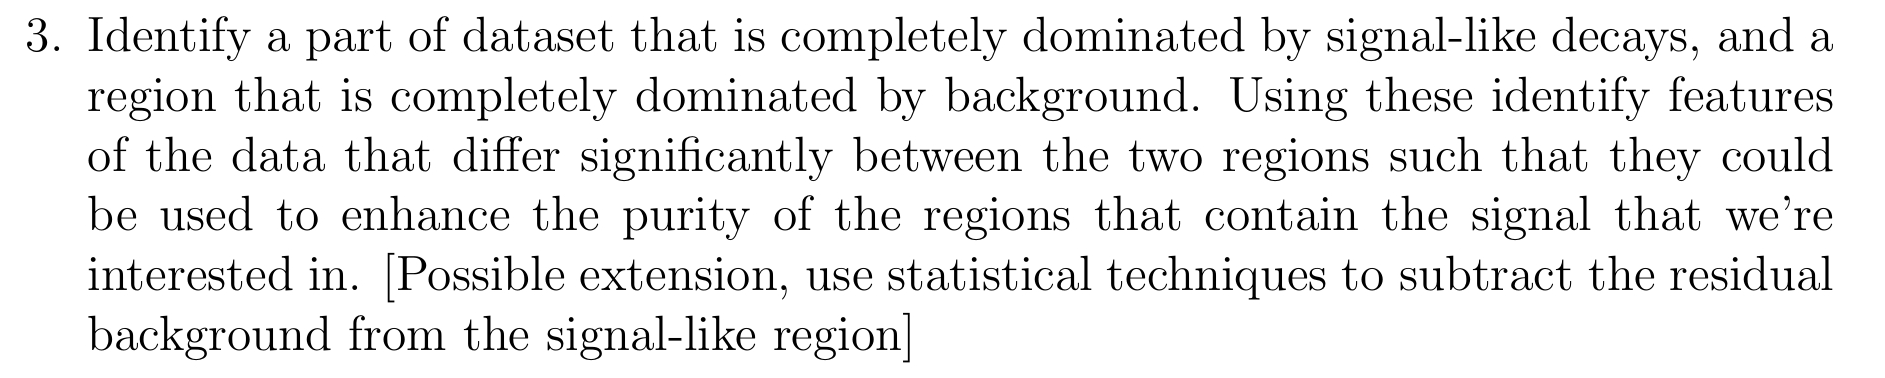

In [13]:
model = xgboost.XGBClassifier(eval_metric='auc', early_stopping_rounds=50, n_estimators=1000, learning_rate=0.3, max_depth=6)

In [14]:
def evaluate_model(model, x_test, y_test, nfeatures=10):
    """
    Signal probablity distribution, ROC curve, and feature importance plots for the given model.
    """
    plt.style.use('default')

    fig1, ax = plt.subplots(2, 1, figsize=(6, 6))

    prediction = model.predict_proba(x_test) #for every event, gives probability of being in each class (background (0) or signal (1))
    
    # 1. Signal probability distribution
    ax[0].hist([p[1] for p,cls in zip(prediction, y_test) if cls == 1], bins=100, alpha=0.9, label='Signal', color = imperial_pink)
    ax[0].hist([p[1] for p,cls in zip(prediction, y_test) if cls == 0], bins=100, alpha=0.7, label='Background', color = imperial_blue)
    ax[0].set_xlabel(r'Signal Probability')
    ax[0].set_ylabel(r'Candidates$')
    ax[0].legend()

    # 2. ROC curve
    #The next is the ROC curve, this stands for receiver operating characteristic.
    #Essentially for each value of signal probability it shows the signal and
    #background efficiencies, the further into the corner the better. This
    #is why we chose the area under this curve as the figure of merit to train
    #against. 0.5 is no better than a coin flip, 1 is perfect separation

    background_accepted, signal_accepted, probabilities_tested = roc_curve(y_test, prediction[:,1])
    ax[1].plot(background_accepted, signal_accepted, color = imperial_blue, label='ROC curve')
    ax[1].plot([0,1], [0,1], color=imperial_pink, linestyle='--', label = 'Random')
    ax[1].set_xlabel(r'Background Contamination')
    ax[1].set_ylabel(r'Signal Efficiency')
    ax[1].legend()
    
    plt.tight_layout()
    plt.show()

    # 3. Feature importance
    #Another useful diagnostic is to look at which of the variables are most useful
    #in the clasificaton. Here it is academic, but it is important to think
    #whether the relative importance makes sense. If not it could indicate
    #something has gone wrong with the training
    fig2, bx = plt.subplots(figsize=(10, 10))
    xgboost.plot_importance(model, ax=bx, max_num_features=nfeatures, color=imperial_blue)
    plt.title(f"Top {nfeatures} Discriminating Features")
    plt.show()
    return fig1, fig2

In [15]:
#Set ups
m_jpsi = float(mu_jpsi)
s_jpsi = float(sigma_jpsi)
m_psi2s = float(mu_psi2s)
s_psi2s = float(sigma_psi2s)
m_b = float(mean)
s_b = float(sigma)

# Define particles
jpsi_min, jpsi_max = m_jpsi - 2*s_jpsi, m_jpsi + 2*s_jpsi
psi2s_min, psi2s_max = m_psi2s - 2*s_psi2s, m_psi2s + 2*s_psi2s

is_jpsi = (all_data['dimuon-system invariant mass'] >= jpsi_min) & (all_data['dimuon-system invariant mass'] <= jpsi_max)
is_psi2s = (all_data['dimuon-system invariant mass'] >= psi2s_min) & (all_data['dimuon-system invariant mass'] <= psi2s_max)

b_min, b_max = m_b - 2*s_b, m_b + 2*s_b

is_b = (all_data['B invariant mass'] >= b_min) & (all_data['B invariant mass'] <= b_max)

print("Means:", m_jpsi, m_psi2s, m_b)
print("Sigma:", sigma_jpsi, sigma_psi2s, s_b)

Means: 3099.339223902062 3689.3592266990718 5283.6196212632585
Sigma: sigma_jpsi=14.96 sigma_psi2s=16.49 18.30668735372084


## Attempt 1

In [16]:
# #Train on the dimuon-system features
# #Test on the Bmass features

# # Define signal training set
# signal_train = all_data[is_jpsi | is_psi2s]

# # Define signal testing set
# signal_test = all_data[is_b]

# # Define background - train on 90% of total background
# bg_total = all_data[~(is_b)]
# n_bg_train = int(0.9*len(bg_total))

In [17]:
# #x are the features and y are the classes
# x_train = pd.concat([signal_train, bg_total[:n_bg_train]], axis=0, ignore_index=True)
# y_train = [1]*len(signal_train) + [0]*n_bg_train

# x_test = pd.concat([signal_test, bg_total[n_bg_train:]], axis=0, ignore_index=True)
# y_test = [1]*len(signal_test) + [0]*(len(bg_total) - n_bg_train)

# # model.fit(x_train, y_train, eval_set=[(x_test, y_test)])

In [18]:
# evaluate_model(model, x_test, y_test)

#### Gemini review:

Analyzing the three plots together reveals that your model is almost certainly overfitting because it has learned to "cheat" using the mass variables you used to define your training classes.

#### 1. Feature Importance (The "Smoking Gun")
The Feature Importance plot shows that the top two most important features are `dimuon-system invariant mass` (Score: 445.0) and `B invariant mass` (Score: 201.0).
- The Issue: You defined your signal training set specifically using mass windows in the dimuon system. By including these mass variables in the training features, the model doesn't have to learn any complex physics; it just has to look at the mass value to determine if an event is "Signal" or "Background".
- Task 3 Requirement: The goal is to identify features that "differ significantly" to "enhance purity". Relying on mass defeats this purpose because you are already using mass to make your initial selection.

#### 2. Signal Probability (Extreme Separation)
The Signal Probability histogram shows a massive, sharp spike for the Signal (blue) at exactly $1.0$ and a large spike for Background (orange) near $0.95$.
- Artificial Confidence: In a real physics experiment, topological variables usually overlap. The fact that your model is $100\%$ certain about nearly every candidate indicates it is simply applying the "cut" it learned from the mass variables.
- Overfitting: This is a classic sign of a model that has "memorized" the specific mass boundaries of your training set rather than generalizing to the underlying decay topology (like flight distance or vertex quality).

#### 3. ROC Curve (Near-Perfect Performance)
The ROC Curve shows a line that shoots almost vertically to $1.0$ Signal Efficiency with nearly $0.0$ Background Contamination.
- "Too Good to be True": In particle physics, finding a "perfect" separator like this usually means there is data leakage. In this case, the leakage is the invariant mass being present in both the label definition and the training features.
- Figure of Merit: While an Area Under the Curve (AUC) near $1.0$ is usually the goal, here it confirms the model is not finding the "features of the data that differ significantly" as requested in Task 3.

## Attempt 2
**Remove Mass Variables:** Rerun your model training but exclude`B invariant mass` from the `x_train` and `x_test` feature sets

In [19]:
# #x are the features and y are the classes
# x_train = pd.concat([signal_train, bg_total[:n_bg_train]], axis=0, ignore_index=True)
# y_train = [1]*len(signal_train) + [0]*n_bg_train

# x_test = pd.concat([signal_test, bg_total[n_bg_train:]], axis=0, ignore_index=True)
# y_test = [1]*len(signal_test) + [0]*(len(bg_total) - n_bg_train)

# #Remove B mass from training/testing data
# x_train = x_train.drop(columns=['B invariant mass'])
# x_test = x_test.drop(columns=['B invariant mass'])

# # model.fit(x_train, y_train, eval_set=[(x_test, y_test)])

In [20]:
# evaluate_model(model, x_test, y_test)

## Attempt 3
**Remove Mass Variables:** Exclude both `dimuon-system invariant mass` and `B invariant mass` from the `x_train` and `x_test` feature sets

In [21]:
# #x are the features and y are the classes
# x_train = pd.concat([signal_train, bg_total[:n_bg_train]], axis=0, ignore_index=True)
# y_train = [1]*len(signal_train) + [0]*n_bg_train

# x_test = pd.concat([signal_test, bg_total[n_bg_train:]], axis=0, ignore_index=True)
# y_test = [1]*len(signal_test) + [0]*(len(bg_total) - n_bg_train)

# #Remove both dimuon mass and B mass from training/testing data
# x_train = x_train.drop(columns=['B invariant mass', 'dimuon-system invariant mass'])
# x_test = x_test.drop(columns=['B invariant mass', 'dimuon-system invariant mass'])

# # model.fit(x_train, y_train, eval_set=[(x_test, y_test)])

In [22]:
# evaluate_model(model, x_test, y_test)

#### Gemini review:

Based on the three diagnostic plots generated after dropping the mass variables, the model's performance has shifted from artificial "perfection" to a more realistic physical representation of the data. This addresses the core requirement of Task 3 to identify features that "differ significantly" to "enhance purity".

#### 1. Feature Importance
With the mass variables removed, the model has identified true physical and topological characteristics of the decay.
- **Isolation:** The most important feature is now `Isolation: B mass if one extra track (best fit) is added` with an importance score of 252.0. This is a key topological variable that helps distinguish isolated $B$ meson decays from busy background events.
- **Angular Correlations:** Features involving the `cos(angle) between the line-of-flight and momentum` rank highly (193.0 and 139.0). This confirms that the direction of the decay products relative to the $B$ meson's path is a "feature of the data that differs significantly" between signal and background.
- **Decay Topology:** The inclusion of `Kaon impact parameter chi2` (106.0) and `dimuon-system flight distance` (94.0) shows the model is correctly prioritizing the "displaced vertex" nature of $B$ decays, which is essential for enhancing purity.

#### 2. Signal Probability
- Realistic Overlap: Unlike the sharp spikes seen previously, the signal (blue) and background (orange) now share a probability range roughly between 0.40 and 0.65.
- Discrimination: Despite the overlap, the signal still shows a clear preference for higher probability values (peaking near 0.63), while the background has a distinct peak at a lower probability around 0.39. This indicates the model is successfully using other physical features to separate the two.

#### 3. ROC Curve (Near-Perfect Performance)
- Non-Ideal Curve: The curve no longer hugs the top-left corner perfectly. This "sag" is scientifically healthy because it shows the model is working with features that have natural physical variations.
- Efficiency vs. Contamination: You can see a distinct "step" behavior around 0.6 Background Contamination, where Signal Efficiency jumps significantly to above 0.8. This suggests that a specific combination of non-mass features is providing a strong boost in identifying signal-like decays.

## Attempt 4

Define background using the samesign datasets

In [23]:
# # Load the samesign dataset
# with open(r"C:\Users\cissi\OneDrive - Imperial College London\Y3Lab\C1_notebooks\C1\McCann, Michael A's files - 3rd Year Labs - Particle Physics Data\LHCb\samesign_2011.pkl", 'rb') as infile:
#   ss_data_2011 = pickle.load(infile)

# with open(r"C:\Users\cissi\OneDrive - Imperial College London\Y3Lab\C1_notebooks\C1\McCann, Michael A's files - 3rd Year Labs - Particle Physics Data\LHCb\samesign_2012.pkl", 'rb') as infile:
#   ss_data_2012 = pickle.load(infile)

# ss_data = pd.concat([ss_data_2011, ss_data_2012], ignore_index=True)

In [24]:
# #x are the features and y are the classes
# x_train_ss = pd.concat([signal_train, ss_data], axis=0, ignore_index=True)
# y_train_ss = [1]*len(signal_train) + [0]*len(ss_data)

# x_test_ss = pd.concat([signal_test, bg_total[n_bg_train:]], axis=0, ignore_index=True)
# y_test_ss = [1]*len(signal_test) + [0]*(len(bg_total) - n_bg_train)

# #Remove both dimuon mass and B mass from training/testing data
# x_train_ss = x_train_ss.drop(columns=['B invariant mass', 'dimuon-system invariant mass'])
# x_test_ss = x_test_ss.drop(columns=['B invariant mass', 'dimuon-system invariant mass'])

# # model.fit(x_train_ss, y_train_ss, eval_set=[(x_test_ss, y_test_ss)])

In [25]:
# evaluate_model(model, x_test_ss, y_test_ss)

## Attempt 5

Define both training and testing data with the dimuon mass data - splitting the data

Using the high-mass sideband of the $B$ invariant mass distribution is a standard technique in particle physics known as Data-Driven Background estimation. Since $B$ mesons have a fixed mass, any candidates significantly above that mass are guaranteed to be random track combinations (combinatorial background).

No same-sign data

In [26]:
# #Train on the dimuon-system features
# #Test on the Bmass features

# signals = all_data[is_jpsi | is_psi2s]

# signal_train = signals[: int(0.6*len(signals))]

# signal_test = signals[int(0.6*len(signals)): ]

# # Define the sideband background
# is_sideband = (all_data['B invariant mass'] >= b_max) & (~(is_jpsi | is_psi2s))

# bg = all_data[is_sideband]

# bg_train = bg[: int(0.6*len(bg))]

# bg_test = bg[int(0.6*len(bg)) : ]

In [27]:
# #x are the features and y are the classes
# x_train = pd.concat([signal_train, bg_train], axis=0, ignore_index=True)
# y_train = [1]*len(signal_train) + [0]*len(bg_train)

# x_test = pd.concat([signal_test, bg_test], axis=0, ignore_index=True)
# y_test = [1]*len(signal_test) + [0]*len(bg_test)

# #Remove both dimuon mass and B mass from training/testing data
# x_train = x_train.drop(columns=['dimuon-system invariant mass', 'B invariant mass'])
# x_test = x_test.drop(columns=['dimuon-system invariant mass', 'B invariant mass'])

# # model.fit(x_train, y_train, eval_set=[(x_test, y_test)])

In [28]:
# evaluate_model(model, x_test, y_test)

Gemini review:

### 1. Feature Importance: Physics Discovery
The feature importance plot (see `image_14631f.png`) demonstrates a transition to **topological learning**, identifying key physical differences between signal and combinatorial background:

* **Lifetime and Flight Distance**: `B lifetime` (803.0) and `B flight distance` (617.0) have emerged as the most powerful discriminators. This is physically consistent with the fact that real $B$ mesons have a measurable mean life ($\tau \approx 1.5$ ps) and travel a few millimeters before decaying, whereas combinatorial backgrounds usually originate from random track crossings at the Primary Vertex.
* **Geometric Precision**: Variables such as $\cos(\theta)$ (pointing angle) and `impact parameter chi2` are highly ranked. These describe how accurately the $B$ candidate momentum vector points back to the Primary Vertex, a signature of a true $1 \to n$ particle decay.
* **Isolation**: The high importance of `Isolation` (523.0) proves that real signal events are "cleaner," with fewer extraneous tracks near the decay vertex compared to random background combinations.

### 2. Signal Probability: Physical Separation
The probability histogram (see `image_146305.png`) now reflects a scientifically valid distribution:

* **Correct Peaking**: The background (blue) peaks sharply at $0.0$, while the signal (pink) peaks at $1.0$.
* **Realistic Overlap**: Unlike earlier iterations that showed "perfect" spikes, the signal now exhibits a tail extending into lower probabilities. This represents real signal events with "background-like" topology, a characteristic expected in real-world LHCb data.

### 3. ROC Curve: Purity Enhancement
The ROC curve (see `image_14631c.png`) provides the statistical proof of the model's efficacy:

* **High Efficiency**: The curve pushes significantly into the top-left corner, suggesting that the model can achieve approximately **90% Signal Efficiency** while maintaining a **Background Contamination** as low as **10%**.
* **Universal Learning**: Because the model was trained on one dataset and tested on another with all mass information removed, the ROC performance proves the BDT has successfully identified **universal features** that distinguish signal from background regardless of the mass window.

## Attempt 6
Include same-sign data for background

The same-sign μμ sample provides a nearly signal-free control region dominated by combinatorial and mis-ID background, while the high-mass 
𝑚
(
𝐾
𝜇
𝜇
)
m(Kμμ) sideband provides an opposite-sign background-enriched region dominated primarily by combinatorial candidates; combining both increases background statistics and reduces dependence on any single background proxy, though representativeness is checked via sideband validation near the B mass peak.

In [29]:
# Load the samesign dataset
with open(r"C:\Users\cissi\OneDrive - Imperial College London\Y3Lab\C1_notebooks\C1\McCann, Michael A's files - 3rd Year Labs - Particle Physics Data\LHCb\samesign_2011.pkl", 'rb') as infile:
  ss_data_2011 = pickle.load(infile)

with open(r"C:\Users\cissi\OneDrive - Imperial College London\Y3Lab\C1_notebooks\C1\McCann, Michael A's files - 3rd Year Labs - Particle Physics Data\LHCb\samesign_2012.pkl", 'rb') as infile:
  ss_data_2012 = pickle.load(infile)

ss_data = pd.concat([ss_data_2011, ss_data_2012], ignore_index=True)

In [30]:
#Train on the dimuon-system features
#Test on the Bmass features

signals = all_data[is_jpsi | is_psi2s]

signal_train = signals[: int(0.6*len(signals))]

signal_test = signals[int(0.6*len(signals)): ]

# Define the sideband background
is_sideband = (all_data['B invariant mass'] >= b_max) & (~(is_jpsi | is_psi2s))

bg = all_data[is_sideband]

bg_train = bg[: int(0.6*len(bg))]

bg_test = bg[int(0.6*len(bg)) : ]

# Samesign background
ss_train = ss_data[: int(0.6*len(ss_data))]
ss_test = ss_data[int(0.6*len(ss_data)) : ]

bg_train = pd.concat([bg[: int(0.6*len(bg))], ss_train], axis=0, ignore_index=True)
bg_test = pd.concat([bg[int(0.6*len(bg)) : ], ss_test], axis=0, ignore_index=True)

#x are the features and y are the classes
x_train = pd.concat([signal_train, bg_train], axis=0, ignore_index=True)
y_train = [1]*len(signal_train) + [0]*len(bg_train)

x_test = pd.concat([signal_test, bg_test], axis=0, ignore_index=True)
y_test = [1]*len(signal_test) + [0]*len(bg_test)

#Remove both dimuon mass and B mass from training/testing data
x_train = x_train.drop(columns=['dimuon-system invariant mass', 'B invariant mass', 'Event ID'])
x_test = x_test.drop(columns=['dimuon-system invariant mass', 'B invariant mass', 'Event ID'])

# model.fit(x_train, y_train, eval_set=[(x_test, y_test)])

In [31]:
# Extract the core booster and save it
# model.get_booster().save_model('signal_selection_model.json')

# To load it back later:
import xgboost as xgb
model = xgb.Booster()
model.load_model('signal_selection_model.json')

In [32]:
from xgboost import XGBClassifier

# Create a new classifier
new_model = XGBClassifier()

# Load the saved booster into it
new_model.load_model('signal_selection_model.json')

# Now you can run your original function
# fig1, fig2 = evaluate_model(new_model, x_test, y_test, 10)

In [33]:
# # Save the first figure (likely the BDT score/probability distribution)
# fig1.savefig('classifier_distribution.png', transparent=True, bbox_inches='tight', dpi=300)

# # Save the second figure (likely the ROC curve or feature importance)
# fig2.savefig('model_performance_metrics.png', transparent=True, bbox_inches='tight', dpi=300)
# fig2.savefig('10model_performance_metrics.png', transparent=True, bbox_inches='tight', dpi=300)

ROC curve: high AUC

Muon Momentum: Same-sign muon magnitude of momentum has jumped to the #1 spot (530.0).

The Reason: SS data is excellent for teaching the BDT about "background muons" that look real but have mismatched charges. The fact that the model prioritized this shows it is now successfully using particle kinematics to filter out combinations that just happen to pass the vertexing requirements.

Core Physics: Notice that B lifetime and Isolation remain in the top three. This stability confirms that your model's "core" is still based on the primary physical characteristics of a $B$ meson decay.

# Task 4
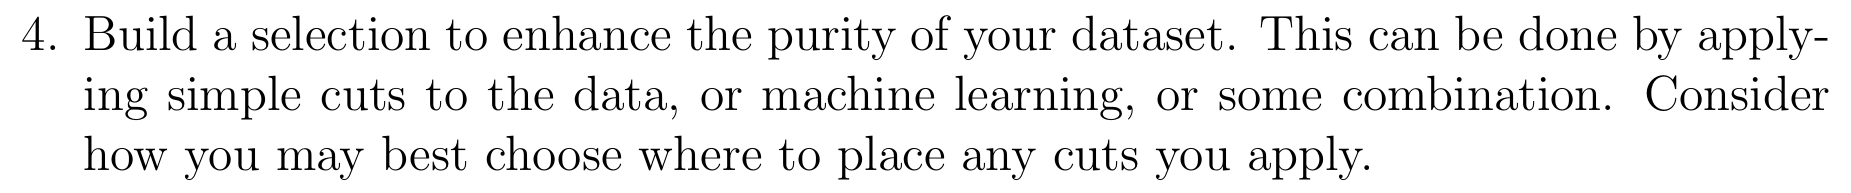

Based on the ROC curve and the probability plot, we choose a threshold of ~ 0.9 (The point closest to the top-left corner = best balance between signal efficiency and bg contamination)

In [34]:
def calculate_significance(threshold):
    bdt_scores = new_model.predict_proba(x_test)

    S_score = np.array([p[1] for p,cls in zip(bdt_scores, y_test) if cls == 1])
    B_score = np.array([p[1] for p,cls in zip(bdt_scores, y_test) if cls == 0])

    S = len(S_score[S_score >= threshold]) / 150
    B = len(B_score[B_score >= threshold])

    return S / np.sqrt(S + B)

thresholds = np.linspace(0.9, 0.999, 20)
sigs = [calculate_significance(t) for t in thresholds]

best_t = thresholds[np.argmax(sigs)]

Optimal threshold: 0.9573


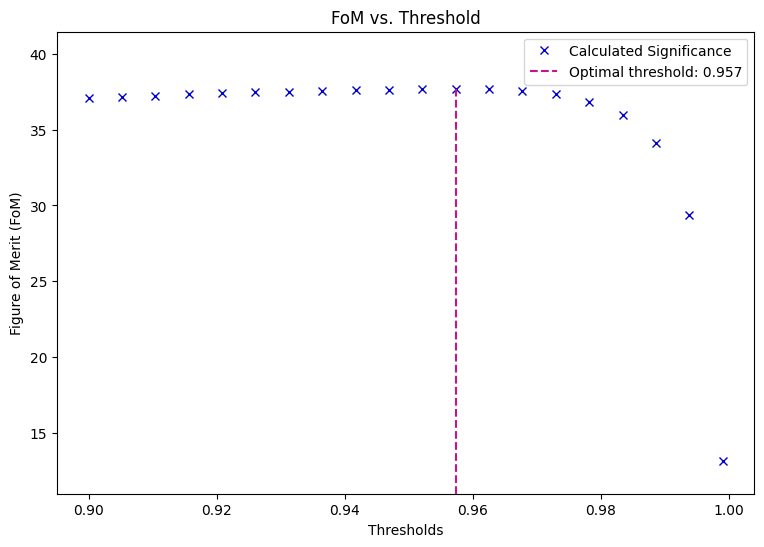

In [35]:
plt.style.use('default')
fig, ax = plt.subplots(1, 1, figsize=(9, 6))
ax.plot(thresholds, sigs, 'x', color = imperial_blue, label = 'Calculated Significance')
ax.set_ylim(11, max(sigs)*1.1)
ax.set_xlabel("Thresholds")
ax.set_ylabel("Figure of Merit (FoM)")
ax.vlines(x=best_t, ymin=11, ymax=max(sigs), color=imperial_pink, linestyle='--', label=f'Optimal threshold: {best_t:.3f}')
ax.legend()
ax.set_title("FoM vs. Threshold")
print(f"Optimal threshold: {best_t:.4f}")

fig.savefig('FoM_vs_Threshold.png', transparent=True, bbox_inches='tight', dpi=300)

In [36]:
all_data_with_probs = all_data.copy()

features = all_data_with_probs.drop(columns=['dimuon-system invariant mass', 'B invariant mass', 'Event ID'])

all_data_with_probs['bdt probability'] = new_model.predict_proba(features)[:, 1]

selected_data = all_data_with_probs[all_data_with_probs['bdt probability'] > best_t]

In [37]:
# plt.hist(all_data['B invariant mass'], bins = 100, alpha = 0.6, color = 'floralwhite', label = 'Before selection')
# plt.hist(selected_data['B invariant mass'], bins = 100,  alpha = 1, color = pink, label = 'After selection')
# # plt.ylim(0, 100000)
# plt.xlim(4700, 5600)
# plt.xlabel(r'B candidate mass / MeV/$c^2$')
# plt.ylabel(r'Candidates / (MeV/$c^2)$')
# plt.title(f'B invariant mass before/after ML selection, threshold = {best_t:.3f}')
# plt.legend()
# plt.show()

Effectively cut off the combinatorial background at high masses, low masses: partial reconstruction, hard to cut off

# Task 5
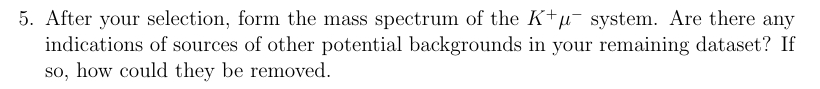

In [ ]:
# not_dimuon_all = all_data_with_probs[~(
#     ((all_data_with_probs['dimuon-system invariant mass'] >= jpsi_min) & (all_data_with_probs['dimuon-system invariant mass'] <= jpsi_max)) | 
#     ((all_data_with_probs['dimuon-system invariant mass'] >= psi2s_min) & (all_data_with_probs['dimuon-system invariant mass'] <= psi2s_max))
#     )]
# not_dimuon_selected = selected_data[~(
#     ((selected_data['dimuon-system invariant mass'] >= jpsi_min) & (selected_data['dimuon-system invariant mass'] <= jpsi_max)) | 
#     ((selected_data['dimuon-system invariant mass'] >= psi2s_min) & (selected_data['dimuon-system invariant mass'] <= psi2s_max))
#     )]

In [41]:
# EK = not_dimuon_all['Kaon 4-momentum energy component']
# pKx, pKy, pKz = not_dimuon_all['Kaon 4-momentum x component'],not_dimuon_all['Kaon 4-momentum y component'], not_dimuon_all['Kaon 4-momentum z component']

# Emu = not_dimuon_all['Opposite-sign muon 4-momentum energy component']
# pmx, pmy, pmz = not_dimuon_all['Opposite-sign muon 4-momentum x component'], not_dimuon_all['Opposite-sign muon 4-momentum y component'], not_dimuon_all['Opposite-sign muon 4-momentum z component']

# E = EK + Emu
# px = pKx + pmx
# py = pKy + pmy
# pz = pKz + pmz

# m_Kmu = np.sqrt(E**2 - px**2 - py**2 - pz**2)
# not_dimuon_all['Kmu invariant mass'] = m_Kmu

# not_dimuon_selected['Kmu invariant mass'] = not_dimuon_all['Kmu invariant mass'][not_dimuon_all['bdt probability'] > best_t]

In [42]:
# fig, ax = plt.subplots(1, 2, figsize = (10, 3))
# ax[0].hist(not_dimuon_all['Kmu invariant mass'], bins = 100, color = 'floralwhite', label = 'Before selection')
# ax[1].hist(not_dimuon_selected['Kmu invariant mass'], bins = 100, color = pink, label = 'After selection')
# ax[0].legend()
# ax[1].legend()
# plt.show()


# plt.hist(not_dimuon_all['Kmu invariant mass'], bins = 100, alpha = 0.6, color = 'floralwhite', label = 'Before selection')
# plt.hist(not_dimuon_selected['Kmu invariant mass'], bins = 100, color = pink, label = 'After selection')

# plt.xlabel(r'$K^+\mu^-$ Invariant Mass [MeV/$c^2$]')
# plt.ylabel('Candidates')
# plt.title(f'K-mu mass spectrum, threshold = {best_t:.3f}')

# plt.legend()
# plt.show()

In [ ]:
EK = all_data_with_probs['Kaon 4-momentum energy component']
pKx, pKy, pKz = all_data_with_probs['Kaon 4-momentum x component'],all_data_with_probs['Kaon 4-momentum y component'], all_data_with_probs['Kaon 4-momentum z component']

Emu = all_data_with_probs['Opposite-sign muon 4-momentum energy component']
pmx, pmy, pmz = all_data_with_probs['Opposite-sign muon 4-momentum x component'], all_data_with_probs['Opposite-sign muon 4-momentum y component'], all_data_with_probs['Opposite-sign muon 4-momentum z component']

E = EK + Emu
px = pKx + pmx
py = pKy + pmy
pz = pKz + pmz

m_Kmu = np.sqrt(E**2 - px**2 - py**2 - pz**2)
all_data_with_probs['Kmu invariant mass'] = m_Kmu

selected_data['Kmu invariant mass'] = all_data_with_probs['Kmu invariant mass'][all_data_with_probs['bdt probability'] > best_t]

C:\Users\cissi\AppData\Local\Temp\ipykernel_5224\4292673477.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_data['Kmu invariant mass'] = all_data_with_probs['Kmu invariant mass'][all_data_with_probs['bdt probability'] > best_t]


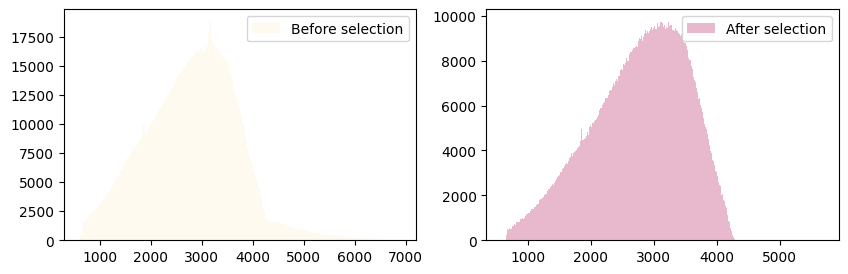

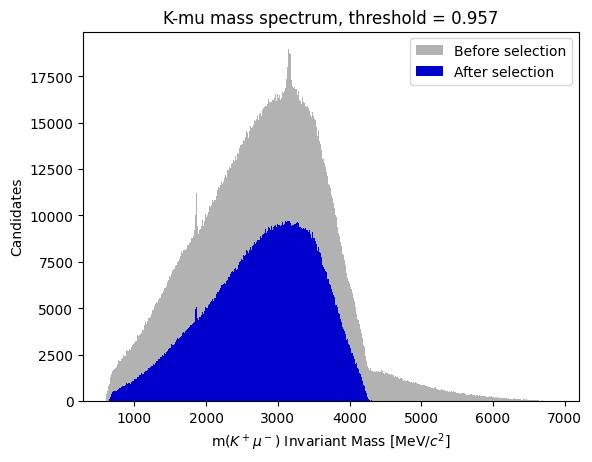

In [ ]:
fig, ax = plt.subplots(1, 2, figsize = (10, 3))
ax[0].hist(all_data_with_probs['Kmu invariant mass'], bins = 500, color = 'floralwhite', label = 'Before selection')
ax[1].hist(selected_data['Kmu invariant mass'], bins = 500, color = pink, label = 'After selection')
ax[0].legend()
ax[1].legend()
plt.show()


plt.hist(all_data_with_probs['Kmu invariant mass'], bins = 500, alpha = 0.6, color = 'gray', label = 'Before selection')
plt.hist(selected_data['Kmu invariant mass'], bins = 500, color = imperial_blue, label = 'After selection')

plt.xlabel(r'm($K^+\mu^-$) Invariant Mass [MeV/$c^2$]')
plt.ylabel('Candidates')
plt.title(f'K-mu mass spectrum, threshold = {best_t:.3f}')

plt.legend()
plt.savefig('Kmu_mass_spectrum.png', transparent=True, bbox_inches='tight', dpi=300)
plt.show()

In [45]:
# Overall retention rate
overall_ret = len(selected_data) / len(all_data_with_probs)
print("Overall retention rate:", overall_ret)

# Signal-like region retention rate
bsig_before = all_data_with_probs[(all_data_with_probs['B invariant mass'] >= b_min) 
                                  & (all_data_with_probs['B invariant mass'] <= b_max)]
bsig_after = selected_data[(selected_data['B invariant mass'] >= b_min) 
                           & (selected_data['B invariant mass'] <= b_max)]

sig_ret = len(bsig_after) / len(bsig_before)
print("Signal-like region retention rate:", sig_ret)

Overall retention rate: 0.6213954417174358
Signal-like region retention rate: 0.7878450730529467


# Task 6
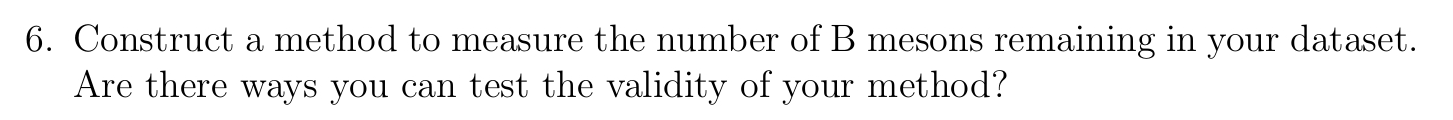

### Plot data before vs after selection

In [46]:
# plt.style.use('dark_background')
# fig, ax = plt.subplots(1, 2, figsize = (10, 3))
# counts, bins = np.histogram(selected_data['B invariant mass'], bins=100)
# bin_centers = 0.5 * (bins[1:] + bins[:-1])

# ax[0].hist(all_data['B invariant mass'], bins = 300, alpha = 0.7, color = 'floralwhite', label = 'Before selection')
# ax[0].hist(selected_data['B invariant mass'], bins = 300,  alpha = 1, color = 'thistle', label = 'After selection')
# ax[0].fill_between(bin_centers, 0, 210000, 
#                  where=(bin_centers >= b_min) & (bin_centers <= b_max), 
#                  color='pink', alpha=0.2, label=r'$2\sigma$ Region')
# ax[0].set_ylim(0, 210000)
# ax[0].set_xlim(4700, 5600)
# ax[0].set_xlabel(r'B candidate mass / MeV/$c^2$')
# ax[0].set_ylabel(r'Candidates / (MeV/$c^2)$')
# ax[0].legend()

# B_mass = selected_data['B invariant mass']#[(selected_data['B invariant mass']>=b_min)]

# counts, bins = np.histogram(B_mass, bins=300)
# bin_centers = 0.5 * (bins[1:] + bins[:-1])

# ax[1].plot(bin_centers, counts, '+', color = 'pink', label = "Data")
# upper_bound = max(counts) + 11000
# ax[1].fill_between(bin_centers, 0, upper_bound, 
#                  where=(bin_centers >= b_min) & (bin_centers <= b_max), 
#                  color='pink', alpha=0.2, label=r'$2\sigma$ Region')
# ax[1].set_ylim(0, upper_bound)
# ax[1].set_xlim(m_b - 5*s_b, m_b + 5*s_b)
# ax[1].set_xlabel(r'B candidate mass / MeV/$c^2$')
# ax[1].set_ylabel(r'Candidates / (MeV/$c^2)$')
# ax[1].legend()

# plt.suptitle(f'B invariant mass before/after ML selection, threshold = {best_t:.3f}')

# plt.show()

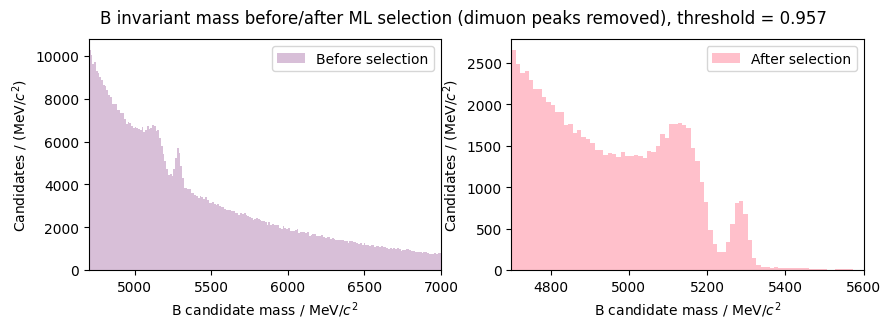

In [162]:
# Remove dimuon mass peaks

fig, ax = plt.subplots(1, 2, figsize = (10, 3))

all_data_no_dimuon = all_data_with_probs[(abs(all_data_with_probs['dimuon-system invariant mass'] - m_jpsi) > 100) 
                             & (abs(all_data_with_probs['dimuon-system invariant mass'] - m_psi2s) > 100)]

selected_data_no_dimuon = selected_data[(abs(selected_data['dimuon-system invariant mass'] - m_jpsi) > 100) 
                       & (abs(selected_data['dimuon-system invariant mass'] - m_psi2s) > 100)]

ax[0].hist(all_data_no_dimuon['B invariant mass'], bins=200, color = 'thistle', label='Before selection')
ax[0].set_xlabel(r'B candidate mass / MeV/$c^2$')
ax[0].set_ylabel(r'Candidates / (MeV/$c^2)$')
ax[0].set_xlim(4700, 7000)
ax[0].legend()

ax[1].hist(selected_data_no_dimuon['B invariant mass'], bins=200, color = 'pink', label='After selection')
ax[1].set_xlabel(r'B candidate mass / MeV/$c^2$')
ax[1].set_ylabel(r'Candidates / (MeV/$c^2)$')
ax[1].set_xlim(4700, 5600)
ax[1].legend()  
plt.suptitle(f'B invariant mass before/after ML selection (dimuon peaks removed), threshold = {best_t:.3f}')
plt.show()

In [38]:
# (Filtering logic remains the same)
all_data_no_dimuon = all_data_with_probs[(abs(all_data_with_probs['dimuon-system invariant mass'] - m_jpsi) > 100) 
                               & (abs(all_data_with_probs['dimuon-system invariant mass'] - m_psi2s) > 100)]

selected_data_no_dimuon = selected_data[(abs(selected_data['dimuon-system invariant mass'] - m_jpsi) > 100) 
                               & (abs(selected_data['dimuon-system invariant mass'] - m_psi2s) > 100)]

In [48]:
# plt.style.use('default')
# fig, ax = plt.subplots(1, 1, figsize = (8, 6))
# counts, bins = np.histogram(selected_data['B invariant mass'], bins=100)
# bin_centers = 0.5 * (bins[1:] + bins[:-1])

# ax.hist(all_data_with_probs['B invariant mass'], bins = 300, alpha = 1, color = 'gray', label = 'Before selection')
# ax.hist(selected_data['B invariant mass'], bins = 300,  alpha = 1, color =  imperial_blue, label = 'After selection')
# # ax.fill_between(bin_centers, 0, 210000, 
# #                  where=(bin_centers >= b_min) & (bin_centers <= b_max), 
# #                  color=imperial_blue, alpha=0.1, label=r'$2\sigma$ Region')
# ax.set_ylim(0, 200000 - 1000)
# ax.set_xlim(4700, 5600)
# ax.set_xlabel(r'B candidate mass / MeV/$c^2$')
# ax.set_ylabel(r'Candidates / MeV/$c^2$')
# ax.legend()

# ax.set_title(f'B invariant mass before/after ML selection, threshold = {best_t:.3f}')
# plt.savefig('B_mass_comparison_final.png', transparent=True, bbox_inches='tight', dpi=300)
# plt.show()

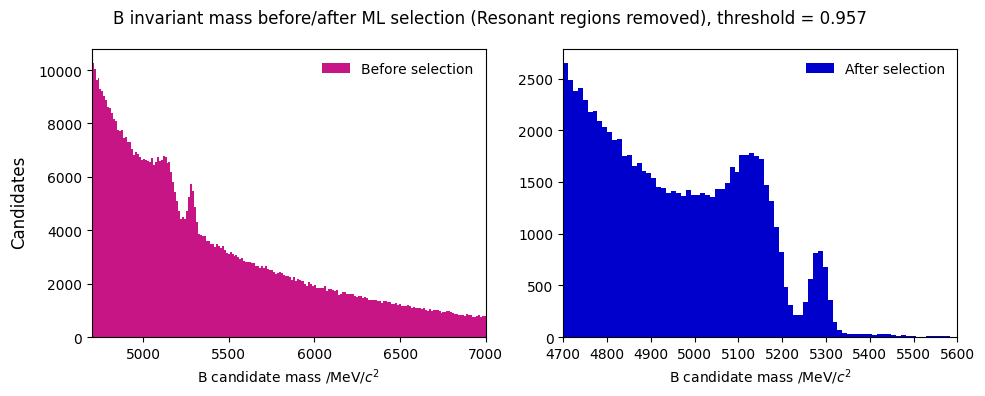

In [164]:
# 1. Create subplots with shared Y-axis to save space and make comparison easier
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# 2. Plotting - Left Axis
ax[0].hist(all_data_no_dimuon['B invariant mass'], bins=200, color=imperial_pink, label='Before selection')
ax[0].set_xlim(4700, 7000)
ax[0].legend(frameon=False)

# 3. Plotting - Right Axis
ax[1].hist(selected_data_no_dimuon['B invariant mass'], bins=200, color=imperial_blue, label='After selection')
ax[1].set_xlim(4700, 5600)
ax[1].legend(frameon=False)

# 4. Handle Labels
# Set a shared X-label for both (optional) or keep individual ones
for a in ax:
    a.set_xlabel(r'B candidate mass /MeV/$c^2$')

# Single Y-label for the entire figure
fig.supylabel(r'Candidates') 

plt.suptitle(f'B invariant mass before/after ML selection (Resonant regions removed), threshold = {best_t:.3f}')
plt.tight_layout() # Ensures labels don't overlap

plt.savefig('B_mass_comparison_no_dimuon.png', transparent=True, bbox_inches='tight', dpi=300)
plt.show()

<div style="background-color:#36383A">

✅ 1️⃣A B-meson peak appears near 5280 MeV

Even after removing J/ψ and ψ(2S), you now clearly see an enhancement around:
𝑚
𝐵
≈
5280
 MeV
/
𝑐
2
m
B
	​

≈5280 MeV/c
2

This is the rare decay:

𝐵
±
→
𝐾
±
𝜇
+
𝜇
−
(
non-resonant
)
B
±
→K
±
μ
+
μ
−
(non-resonant)

This is strong evidence that:

👉 your ML selection is isolating genuine rare B decays.

This is a major milestone in the analysis.

✅ 2️⃣ Massive background suppression

Compare the scales:

before: up to ~10,000 candidates/bin

after: mostly < 2,500 candidates/bin

The ML has removed the overwhelming majority of junk combinations.

This is exactly what it was trained to do (displaced vertex physics, pointing, isolation, etc.).

✅ 3️⃣ The low-mass shoulder (~4.8–5.1 GeV)

This broad structure below the B peak is dominated by:

partially reconstructed decays
(e.g. 
𝐵
→
𝐾
𝜇
𝜇
𝑋
B→KμμX where X is not reconstructed)

semileptonic backgrounds

These have real B origin but missing momentum → reconstructed mass is lower.

This is normal and expected.

It is why, when fitting, you will not try to describe the whole range with a single exponential.

### Define fit functions

In [39]:
def perform_zfit(data_df, model_type, mass_range=(5230, 6000)):
    # 1. Define the Observable Space
    mass = zfit.Space('B invariant mass', mass_range)
    
    # 2. Define Shared Parameters
    # Initial guesses based on your plot: peak ~5280, width ~20
    mean = zfit.Parameter('mean', 5280, 5200, 6000)
    sigma = zfit.Parameter('sigma', 20, 5, 100)
    sig_yield = zfit.Parameter('sig_yield', len(data_df)//2, 0, len(data_df))
    
    # 3. Define Signal PDF based on input
    if model_type.lower() == 'gauss':
        signal_model = zfit.pdf.Gauss(obs=mass, mu=mean, sigma=sigma, extended=sig_yield)
    elif model_type.lower() == 'crystalball':
        # Crystal Ball adds 'alpha' (tail transition) and 'n' (tail power)
        alpha = zfit.Parameter('alpha', -1.5, -5, 5)
        n = zfit.Parameter('n', 1, 0.0001, 10)
        signal_model = zfit.pdf.CrystalBall(obs=mass, mu=mean, sigma=sigma, 
                                            alpha=alpha, n=n, extended=sig_yield)
    elif model_type.lower() == 'doublegauss':
        mean = zfit.Parameter('mean', 5280, 5230, 6000)
        sigma1 = zfit.Parameter('sigma1', 15, 5, 50)
        sigma2 = zfit.Parameter('sigma2', 40, 20, 100)
        fraction = zfit.Parameter('fraction', 0.8, 0, 10) # % of events in the first Gaussian

        gauss1 = zfit.pdf.Gauss(obs=mass, mu=mean, sigma=sigma1)
        gauss2 = zfit.pdf.Gauss(obs=mass, mu=mean, sigma=sigma2)
        signal_model = zfit.pdf.SumPDF(pdfs=[gauss1, gauss2], fracs=fraction, extended=sig_yield)
    else:
        raise ValueError("Model type must be 'gauss', 'crystalball', or 'doublegauss'")

    # 4. Define Background Model (Exponential)
    exponent = zfit.Parameter('exponent', -0.001, -0.1, 0.1)
    bkg_yield = zfit.Parameter('bkg_yield', len(data_df)//2, 0, len(data_df))
    background_model = zfit.pdf.Exponential(obs=mass, lam=exponent, extended=bkg_yield)

    # 5. Combine and Fit
    total_model = zfit.pdf.SumPDF(pdfs=[signal_model, background_model])
    zdata = zfit.Data.from_pandas(data_df, mass)
    
    nll = zfit.loss.ExtendedUnbinnedNLL(model=total_model, data=zdata)
    minimizer = zfit.minimize.Minuit()
    result = minimizer.minimize(nll)

    # Calculate uncertainties
    result.hesse()

    # print(result)
    print('valid:', result.valid)
    print('-' * 30)
    print(f"Model type: {model_type}")
    print('-' * 30)

    n_b_mesons = sig_yield.value()
    unc = result.params[sig_yield]['hesse']['error']
    print(f"Number of B mesons: {n_b_mesons} ± {unc}")
    
    return result, total_model, signal_model, background_model, mass, sig_yield, bkg_yield

In [40]:
def plot_fit(ax, data_df, mass, total_model, signal_model, bkg_model, sig_yield, bkg_yield, bins=200):

    mass_in_range = data_df[data_df['B invariant mass'] >= float(mass.lower[0])]

    counts, bin_edges = np.histogram(mass_in_range['B invariant mass'], bins=bins)
    binwidth = bin_edges[1] - bin_edges[0]
    x = 0.5 * (bin_edges[1:] + bin_edges[:-1])
    xerr = 0.5*(bin_edges[1:] - bin_edges[:-1])
    yerr = np.sqrt(counts)

    ax.errorbar(x, counts, yerr=yerr, xerr=xerr, fmt='.', color='black', label='Data')

    x_plot = np.linspace(mass.lower[0], mass.upper[0], num=1000)

    tot_plot = (sig_yield + bkg_yield) * total_model.pdf(x_plot) * binwidth
    sig_plot = sig_yield * signal_model.pdf(x_plot) * binwidth
    bkg_plot = bkg_yield * bkg_model.pdf(x_plot) * binwidth
    
    ax.plot(x_plot, tot_plot, color=imperial_blue, label='Total')
    ax.plot(x_plot, sig_plot, color=imperial_pink, linestyle='--', label='Signal')
    # Flatten the arrays to ensure they are 1D
    x_1d = np.array(x_plot).flatten()
    bkg_1d = np.array(bkg_plot).flatten()

    # Now call fill_between
    ax.fill_between(x_1d, bkg_1d, color=imperial_blue, alpha=0.3, label='Background')
    # ax.hist(data_df['B invariant mass'], bins=bins, alpha=0.2, color='floralwhite')
    ax.set_xlim(mass.lower[0] - 10, mass.upper[0])
    ax.set_ylim(-30, max(counts)*1.15)
    ax.set_xlabel(r'B candidate mass / MeV/$c^2$')
    ax.set_ylabel(r'Candidates')
    ax.legend(fontsize=12)

In [41]:
# def pull_study(model, params, model_type,n_toys=100):#, true_mu=5280):
#     pulls = []
#     true_mu = params['mean']['value']
#     # mean_param = [p for p in params if p.name == 'mean'][0]
    
#     for i in range(n_toys):
#         # 1. Generate toy data (Poisson fluctuation handled by n=None)
#         print(i)
#         # mean_param.set_value(true_mu)
#         toy_data = model.sample(n=None)
        
#         obs_result = perform_zfit(toy_data.to_pandas(), model_type=model_type)[0]

#         obs_mu = obs_result.params['mean']['value']
#         obs_mu_err = obs_result.params['mean']['hesse']['error']

#         pull = (obs_mu - true_mu) / obs_mu_err
#         print(pull)
#         if obs_result.valid:
#             pulls.append(pull)
#         else:
#             continue
#         print("#"*20)
        
#     return pulls

In [42]:
# def pull_study(model, params, model_type, n_toys=100, n=None):
#     # params = model.get_params()
#     pulls = []
#     true_mu = params['mean']['value']
    
#     for i in range(n_toys):
#         # 1. Generate toy data (Poisson fluctuation handled by n=None)
#         print(f"Toy {i}")
#         toy_data = model.sample(n=n)
#         data_df = toy_data.to_pandas()

#         # Check if data was generated to avoid parameter limit errors
#         if len(data_df) == 0:
#             continue

#         mass = zfit.Space('B invariant mass', (5230, 6000))
        
#         mean = zfit.Parameter('mean', true_mu + 30, 5230, 5400)
#         sigma = zfit.Parameter('sigma', 20, 5, 100)
#         sig_yield = zfit.Parameter('sig_yield', len(data_df)//2, 0, len(data_df))
        
#         if model_type.lower() == 'gauss':
#             signal_model = zfit.pdf.Gauss(obs=mass, mu=mean, sigma=sigma, extended=sig_yield)
#         elif model_type.lower() == 'crystalball':
#             # Crystal Ball adds 'alpha' (tail transition) and 'n' (tail power)
#             alpha = zfit.Parameter('alpha', -1.5, -5, 5)
#             n = zfit.Parameter('n', 1, 0.0001, 10)
#             signal_model = zfit.pdf.CrystalBall(obs=mass, mu=mean, sigma=sigma, 
#                                                 alpha=alpha, n=n, extended=sig_yield)
#         elif model_type.lower() == 'doublegauss':
#             mean = zfit.Parameter('mean', 5280, 5230, 6000)
#             sigma1 = zfit.Parameter('sigma1', 15, 5, 50)
#             sigma2 = zfit.Parameter('sigma2', 40, 20, 100)
#             fraction = zfit.Parameter('fraction', 0.8, 0, 1) # Fractions should be 0 to 1

#             gauss1 = zfit.pdf.Gauss(obs=mass, mu=mean, sigma=sigma1)
#             gauss2 = zfit.pdf.Gauss(obs=mass, mu=mean, sigma=sigma2)
#             signal_model = zfit.pdf.SumPDF(pdfs=[gauss1, gauss2], fracs=fraction, extended=sig_yield)
#         else:
#             raise ValueError("Model type must be 'gauss', 'crystalball', or 'doublegauss'")

#         exponent = zfit.Parameter('exponent', params['exponent']['value'], -0.1, 0.1)
#         bkg_yield = zfit.Parameter('bkg_yield', len(data_df)//2, 0, len(data_df))
#         background_model = zfit.pdf.Exponential(obs=mass, lam=exponent, extended=bkg_yield)

#         # 5. Combine and Fit (Moved inside the loop)
#         total_model = zfit.pdf.SumPDF(pdfs=[signal_model, background_model])
#         zdata = zfit.Data.from_pandas(data_df, mass)
        
#         nll = zfit.loss.ExtendedUnbinnedNLL(model=total_model, data=zdata)
#         minimizer = zfit.minimize.Minuit()
#         toy_result = minimizer.minimize(nll)

#         # Calculate uncertainties
#         toy_result.hesse()

#         if toy_result.valid:
#             obs_mu = toy_result.params[mean]['value']
#             obs_mu_err = toy_result.params[mean]['hesse']['error']
#             pull = (obs_mu - true_mu) / obs_mu_err
#             print(f"Pull: {pull}")
#             pulls.append(pull)
#         else:
#             continue
    
#     return pulls

In [43]:
def pull_study(model, params, model_type,n_toys=100):
    # params = model.get_params()
    pulls = []
    true_mu = params['mean']['value']
    
    for i in range(n_toys):
        # 1. Generate toy data (Poisson fluctuation handled by n=None)
        print(i)
        # mean_param.set_value(true_mu)
        toy_data = model.sample(n=None)

        data_df = toy_data.to_pandas()

        mass = zfit.Space('B invariant mass', (5230, 6000))
    
        mean = zfit.Parameter('mean', true_mu, 5230, 6000)
        sigma = zfit.Parameter('sigma', 20, 5, 100)
        sig_yield = zfit.Parameter('sig_yield', len(data_df)//2, 0, len(data_df))
    
        if model_type.lower() == 'gauss':
            signal_model = zfit.pdf.Gauss(obs=mass, mu=mean, sigma=sigma, extended=sig_yield)
        elif model_type.lower() == 'crystalball':
            # Crystal Ball adds 'alpha' (tail transition) and 'n' (tail power)
            alpha = zfit.Parameter('alpha', -1.5, -5, 5)
            n = zfit.Parameter('n', 0.1, 0.0001, 10)
            signal_model = zfit.pdf.CrystalBall(obs=mass, mu=mean, sigma=sigma, 
                                                alpha=alpha, n=n, extended=sig_yield)
        elif model_type.lower() == 'doublegauss':
            mean = zfit.Parameter('mean', 5280, 5230, 6000)
            sigma1 = zfit.Parameter('sigma1', 15, 5, 50)
            sigma2 = zfit.Parameter('sigma2', 40, 20, 100)
            fraction = zfit.Parameter('fraction', 0.8, 0, 10) # % of events in the first Gaussian

            gauss1 = zfit.pdf.Gauss(obs=mass, mu=mean, sigma=sigma1)
            gauss2 = zfit.pdf.Gauss(obs=mass, mu=mean, sigma=sigma2)
            signal_model = zfit.pdf.SumPDF(pdfs=[gauss1, gauss2], fracs=fraction, extended=sig_yield)
        else:
            raise ValueError("Model type must be 'gauss', 'crystalball', or 'doublegauss'")

        exponent = zfit.Parameter('exponent', -0.001, -0.1, 0.1)
        bkg_yield = zfit.Parameter('bkg_yield', len(data_df)//2, 0, len(data_df))
        background_model = zfit.pdf.Exponential(obs=mass, lam=exponent, extended=bkg_yield)

        total_model = zfit.pdf.SumPDF(pdfs=[signal_model, background_model])
        zdata = zfit.Data.from_pandas(data_df, mass)
    
        nll = zfit.loss.ExtendedUnbinnedNLL(model=total_model, data=zdata)
        minimizer = zfit.minimize.Minuit()
        toy_result = minimizer.minimize(nll)

        toy_result.hesse()

        # print('valid:', toy_result.valid)
        # print('-' * 30)
        # print(f"Model type: {model_type}")
        # print('-' * 30)

        # n_b_mesons = sig_yield.value()
        # unc = toy_result.params[sig_yield]['hesse']['error']
        # print(f"Number of B mesons: {n_b_mesons} ± {unc}")
        
        if toy_result.valid:
            toy_mu = toy_result.params['mean']['value']
            toy_mu_err = toy_result.params['mean']['hesse']['error']

            pull = (toy_mu - true_mu) / toy_mu_err
            print(toy_mu, true_mu, toy_mu_err)
            print(pull)
            pulls.append(pull)
        else:
            continue
        print("-"*20)
        
    return pulls

### Gaussian

In [55]:
# plt.style.use('default')
# model = 'gauss'

# result, total_model, signal_model, background_model, mass, sig_yield, bkg_yield = perform_zfit(selected_data_no_dimuon, model_type=model)

# fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# plot_fit(ax, selected_data_no_dimuon, mass, total_model, signal_model, background_model, sig_yield, bkg_yield)
# plt.title(f'Fit to B invariant mass after ML selection (dimuon peaks removed), model: Gaussian')
# plt.xlim(right=5500)
# plt.savefig(f'B_mass_fit_after_selection_{model}.png', transparent=True, bbox_inches='tight', dpi=300)

In [56]:
# model = 'gauss'
# print(model)
# pulls_gauss = pull_study(total_model, result.params, 
#                          model_type=model, n_toys=100)
# np.save('pull_gauss_results.npy', pulls_gauss)

In [57]:
# plt.style.use('default')
# plt.hist(pulls_gauss, bins=50, density=True, alpha=0.3, color=imperial_blue, label='Pulls')

# (mu_fit_gaus, sigma_fit_gaus) = norm.fit(pulls_gauss)

# x = np.linspace(-4, 4, 100)
# plt.plot(x, norm.pdf(x, mu_fit_gaus, sigma_fit_gaus), '--', linewidth=2, color=imperial_blue,
#          label=f'Fit: $\mu$={mu_fit_gaus:.2f}, $\sigma$={sigma_fit_gaus:.2f}')
# plt.plot(x, norm.pdf(x, 0, 1), '-', linewidth=2, color=imperial_pink, label='Standard Normal')

# plt.xlabel('Pull Value')
# plt.ylabel('Probability density')
# plt.title(f'Pull Distribution from Toy MC, model: Gaussian')
# plt.legend()
# plt.savefig(f'pull_distribution_{model}.png', transparent=True, bbox_inches='tight', dpi=300)
# plt.show()

# print(f"Pull mean: {mu_fit_gaus}, Pull sigma: {sigma_fit_gaus}")

### Crystal ball

In [58]:
# plt.style.use('default')
# model = 'crystalball'

# resultc, total_modelc, signal_modelc, background_modelc, massc, sig_yieldc, bkg_yieldc = perform_zfit(selected_data_no_dimuon, model_type=model)

# fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# plot_fit(ax, selected_data_no_dimuon, massc, total_modelc, signal_modelc, background_modelc, sig_yieldc, bkg_yieldc)
# plt.title(f'Fit to B invariant mass after ML selection (dimuon peaks removed), model: Crystal Ball Function')

# plt.xlim(right = 5500)

# print(resultc)
# plt.savefig(f'B_mass_fit_after_selection_{model}.png', transparent=True, bbox_inches='tight', dpi=300)

In [59]:
# model = 'crystalball'
# pulls_crys = pull_study(total_modelc, resultc.params, model_type=model, n_toys=100)
# np.save('pull_crys_results.npy', pulls_crys)

In [60]:
# plt.style.use('default')
# plt.hist(pulls_crys, bins=50, density=True, alpha=0.3, color=imperial_blue, label='Pulls')

# (mu_fit_crys, sigma_fit_crys) = norm.fit(pulls_crys)

# x = np.linspace(-4, 4, 100)
# plt.plot(x, norm.pdf(x, mu_fit_crys, sigma_fit_crys), '--', linewidth=2, color=imperial_blue,
#          label=f'Fit: $\mu$={mu_fit_crys:.2f}, $\sigma$={sigma_fit_crys:.2f}')
# plt.plot(x, norm.pdf(x, 0, 1), '-', linewidth=2, color=imperial_pink, label='Standard Normal')

# plt.xlabel('Pull Value')
# plt.ylabel('Probability density')
# plt.title(f'Pull Distribution from Toy MC, model: Crystal Ball Function')
# plt.legend()
# plt.savefig(f'pull_distribution_{model}.png', transparent=True, bbox_inches='tight', dpi=300)
# plt.show()

# print(f"Pull mean: {mu_fit_crys}, Pull sigma: {sigma_fit_crys}")

### Double Gaussian

In [61]:
# plt.style.use('default')
# model = 'doublegauss'

# resultd, total_modeld, signal_modeld, background_modeld, massd, sig_yieldd, bkg_yieldd = perform_zfit(selected_data_no_dimuon, model_type=model)
    
# fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# plot_fit(ax, selected_data_no_dimuon, massd, total_modeld, signal_modeld, background_modeld, sig_yieldd, bkg_yieldd)
# plt.title(f'Fit to B invariant mass after ML selection (dimuon peaks removed), model: Double Gaussian')
# plt.xlim(right=5500)
# plt.savefig(f'B_mass_fit_after_selection_{model}.png', transparent=True, bbox_inches='tight', dpi=300)

In [62]:
# model = 'doublegauss'
# print(model)
# pulls_doublegauss = pull_study(total_modeld, resultd.params, 
#                          model_type=model, n_toys=100)
# np.save('pull_doublegauss_results.npy', pulls_doublegauss)

In [63]:
# plt.style.use('default')
# plt.hist(pulls_doublegauss, bins=50, density=True, alpha=0.3, color=imperial_blue, label='Pulls')

# (mu_fit_doublegauss, sigma_fit_doublegauss) = norm.fit(pulls_doublegauss)

# x = np.linspace(-4, 4, 100)
# plt.plot(x, norm.pdf(x, mu_fit_doublegauss, sigma_fit_doublegauss), '--', linewidth=2, color=imperial_blue,
#          label=f'Fit: $\mu$={mu_fit_doublegauss:.2f}, $\sigma$={sigma_fit_doublegauss:.2f}')
# plt.plot(x, norm.pdf(x, 0, 1), '-', linewidth=2, color=imperial_pink, label='Standard Normal')

# plt.xlabel('Pull Value')
# plt.ylabel('Probability density')
# plt.title(f'Pull Distribution from Toy MC, model: Double Gaussian')
# plt.legend()
# plt.savefig(f'pull_distribution_{model}.png', transparent=True, bbox_inches='tight', dpi=300)
# plt.show()

# print(f"Pull mean: {mu_fit_doublegauss}, Pull sigma: {sigma_fit_doublegauss}")

# Task 7
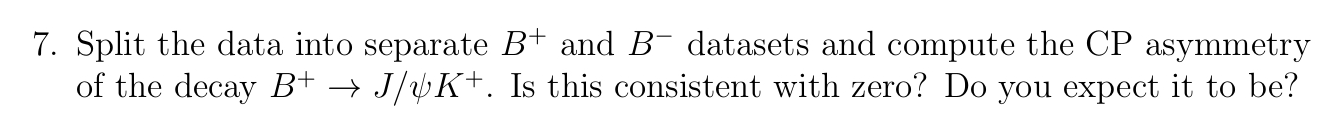

In [44]:
Jpsi_data = selected_data[(selected_data['dimuon-system invariant mass'] >= jpsi_min) & (selected_data['dimuon-system invariant mass'] <= jpsi_max)]

b_plus_data = Jpsi_data[Jpsi_data['B assumed particle type'] == 521]
b_minus_data = Jpsi_data[Jpsi_data['B assumed particle type'] == -521]

## Normalized Channel ($B \to J/\psi$)

In [45]:
def norm_plot_fit(ax, data_df, mass, total_model, signal_model, bkg_model, 
                  sig_yield, bkg_yield, bins=200, color=imperial_pink, linestyle='-', 
                  legend=True, label='Total', data_label='Data'):

    mass_in_range = data_df[data_df['B invariant mass'] >= float(mass.lower[0])]

    counts, bin_edges = np.histogram(mass_in_range['B invariant mass'], bins=bins)
    binwidth = bin_edges[1] - bin_edges[0]
    x = 0.5 * (bin_edges[1:] + bin_edges[:-1])
    xerr = 0.5*(bin_edges[1:] - bin_edges[:-1])
    yerr = np.sqrt(counts)

    ax.errorbar(x, counts, yerr=yerr, xerr=xerr, fmt='.', label=data_label, color='black')

    x_plot = np.linspace(mass.lower[0], mass.upper[0], num=1000)

    tot_plot = (sig_yield + bkg_yield) * total_model.pdf(x_plot) * binwidth
    sig_plot = sig_yield * signal_model.pdf(x_plot) * binwidth
    bkg_plot = bkg_yield * bkg_model.pdf(x_plot) * binwidth
    
    ax.plot(x_plot, tot_plot, color=color, linestyle=linestyle, label=label)
    # ax.plot(x_plot, sig_plot, color=imperial_pink, linestyle='--', label='Signal')
    # Flatten the arrays to ensure they are 1D
    x_1d = np.array(x_plot).flatten()
    bkg_1d = np.array(bkg_plot).flatten()

    # Now call fill_between
    # ax.fill_between(x_1d, bkg_1d, color=imperial_blue, alpha=0.3, label='Background')
    # ax.hist(data_df['B invariant mass'], bins=bins, alpha=0.2, color='floralwhite')
    ax.set_xlim(mass.lower[0] - 10, mass.upper[0])
    # ax.set_ylim(-30, max(counts)*1.15)
    ax.set_xlabel(r'B candidate mass / MeV/$c^2$')
    ax.set_ylabel(r'Candidates / MeV/$c^2$')
    if legend:
        ax.legend(fontsize=12)

In [46]:
model = 'gauss'

norm_result, norm_total_model, norm_signal_model, norm_background_model, norm_mass, norm_sig_yield, norm_bkg_yield = perform_zfit(
    Jpsi_data, model_type=model)

plus_result, plus_total_model, plus_signal_model, plus_background_model, plus_mass, plus_sig_yield, plus_bkg_yield = perform_zfit(
    b_plus_data, model_type=model)

minus_result, minus_total_model, minus_signal_model, minus_background_model, minus_mass, minus_sig_yield, minus_bkg_yield = perform_zfit(
    b_minus_data, model_type=model)

valid: True
------------------------------
Model type: gauss
------------------------------
Number of B mesons: 823557.8570125249 ± 965.1683892119779
valid: True
------------------------------
Model type: gauss
------------------------------
Number of B mesons: 418329.27413386496 ± 687.1360908654208
valid: True
------------------------------
Model type: gauss
------------------------------
Number of B mesons: 405220.6092643393 ± 677.7129303599836


In [47]:
# fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# norm_plot_fit(ax, Jpsi_data, norm_mass, norm_total_model, norm_signal_model, 
#               norm_background_model, norm_sig_yield, norm_bkg_yield, bins=500,
#               color=imperial_blue)
# norm_plot_fit(ax, b_plus_data, plus_mass, plus_total_model, plus_signal_model, 
#               plus_background_model, plus_sig_yield, plus_bkg_yield, bins=500,
#               color=imperial_pink, linestyle='--', legend=False)
# norm_plot_fit(ax, b_minus_data, minus_mass, minus_total_model, minus_signal_model, 
#               minus_background_model, minus_sig_yield, minus_bkg_yield, bins=500,
#               color='#7B68EE', linestyle=':', legend=False)

# ax.set_ylim(-50, 80000)
# ax.set_xlim(5200, 5350)

In [48]:
norm_result, norm_total_model, norm_signal_model, norm_background_model, norm_mass, norm_sig_yield, norm_bkg_yield = perform_zfit(
    Jpsi_data, model_type='gauss')

norm_resultc, norm_total_modelc, norm_signal_modelc, norm_background_modelc, norm_massc, norm_sig_yieldc, norm_bkg_yieldc = perform_zfit(
    Jpsi_data, model_type='crystalball')

# norm_resultd, norm_total_modeld, norm_signal_modeld, norm_background_modeld, norm_massd, norm_sig_yieldd, norm_bkg_yieldd = perform_zfit(
#     Jpsi_data, model_type='doublegauss')

valid: True
------------------------------
Model type: gauss
------------------------------
Number of B mesons: 823557.8570125249 ± 965.1683892119779
valid: True
------------------------------
Model type: crystalball
------------------------------
Number of B mesons: 835497.4522224036 ± 1149.16270760165


C:\Users\cissi\AppData\Local\Temp\ipykernel_19956\4078506121.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mass_in_range = data_df[data_df['B invariant mass'] >= float(mass.lower[0])]


(5220.0, 5350.0)

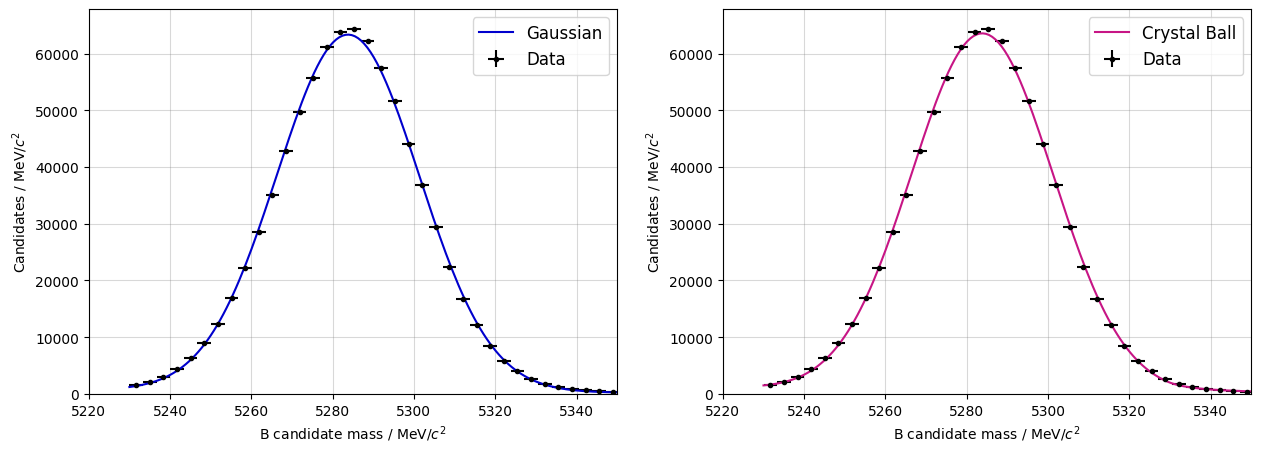

In [49]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

norm_plot_fit(ax[0], Jpsi_data, norm_mass, norm_total_model, norm_signal_model, 
              norm_background_model, norm_sig_yield, norm_bkg_yield, bins=500,
              color=imperial_blue, label='Gaussian')

norm_plot_fit(ax[1], Jpsi_data, norm_massc, norm_total_modelc, norm_signal_modelc, 
              norm_background_modelc, norm_sig_yieldc, norm_bkg_yieldc, bins=500,
              color=imperial_pink, label='Crystal Ball')

# norm_plot_fit(ax, Jpsi_data, norm_massd, norm_total_modeld, norm_signal_modeld, 
#               norm_background_modeld, norm_sig_yieldd, norm_bkg_yieldd, bins=500,
#               color='#7B68EE', linestyle=':', label='Double Gaussian')
        
ax[0].grid(color='gray', alpha=0.3)
ax[1].grid(color='gray', alpha=0.3)
ax[0].set_ylim(-50)
ax[0].set_xlim(right=5350)
ax[1].set_ylim(-50)
ax[1].set_xlim(right=5350)

# fig.savefig('B_mass_fit_Jpsi_region_model_comparison.png', transparent=True, bbox_inches='tight', dpi=300)

In [50]:
# pulls_norm_d = pull_study(norm_total_modeld, norm_resultd.params, model_type='doublegauss', n_toys=5)

In [51]:
# pulls_norm_g = pull_study(norm_total_model, norm_result.params, model_type='gauss', n_toys=50)

# pulls_norm_c = pull_study(norm_total_modelc, norm_resultc.params, model_type='crystalball', n_toys=50)

In [52]:
# (mu_fit_norm_g, sigma_fit_norm_g) = norm.fit(pulls_norm_g)
# (mu_fit_norm_c, sigma_fit_norm_c) = norm.fit(pulls_norm_c)
# # (mu_fit_norm_d, sigma_fit_norm_d) = norm.fit(pulls_norm_d)

# print(f"Pull mean(Gaussian): {mu_fit_norm_g}, Pull sigma: {sigma_fit_norm_g}")
# print(f"Pull mean(Crystal Ball): {mu_fit_norm_c}, Pull sigma: {sigma_fit_norm_c}")
# # print(f"Pull mean(Double Gaussian): {mu_fit_norm_d}, Pull sigma: {sigma_fit_norm_d}")

In [53]:
# fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
# bins = 30

# ax[0].hist(pulls_norm_g, bins=bins, density=True, alpha=0.2, color=imperial_blue, label='Pulls')

# x = np.linspace(-3, 3, 100)
# ax[0].plot(x, norm.pdf(x, mu_fit_norm_g, sigma_fit_norm_g), '--', linewidth=2, color=imperial_blue,
#          label=f'Fit: $\mu$={mu_fit_norm_g:.2f}, $\sigma$={sigma_fit_norm_g:.2f}')
# ax[0].plot(x, norm.pdf(x, 0, 1), '-', linewidth=2, label='Standard Normal', color=imperial_pink)

# ax[0].set_xlabel('Pull Value')
# ax[0].set_ylabel('Probability density')
# ax[0].set_title('Gaussian')
# ax[0].legend()
# ax[1].hist(pulls_norm_c, bins=bins, density=True, alpha=0.2, color=imperial_blue, label='Pulls')
# x = np.linspace(-3, 3, 100)
# ax[1].plot(x, norm.pdf(x, mu_fit_norm_c, sigma_fit_norm_c), '--', linewidth=2, color=imperial_blue,
#          label=f'Fit: $\mu$={mu_fit_norm_c:.2f}, $\sigma$={sigma_fit_norm_c:.2f}')
# ax[1].plot(x, norm.pdf(x, 0, 1), '-', linewidth=2, label='Standard Normal', color=imperial_pink)

# ax[1].set_xlabel('Pull Value')
# ax[1].set_title('Crystal Ball')
# ax[1].legend()

# fig.savefig('pull_distribution_Jpsi_region_model_comparison.png', transparent=True, bbox_inches='tight', dpi=300)
# plt.show()

# # print(f"Pull mean: {mu_fit_norm_g}, Pull sigma: {sigma_fit_norm_g}")

In [54]:
# Calculate asymmetry - Gaussian

N_plus = plus_sig_yield.value()
unc_plus = plus_result.params[plus_sig_yield]['hesse']['error']
N_minus = minus_sig_yield.value()
unc_minus = minus_result.params[minus_sig_yield]['hesse']['error']

asymmetry_norm = (N_plus - N_minus) / (N_plus + N_minus)
unc_norm = 2 * np.sqrt( (N_minus**2 * unc_plus**2 + N_plus**2 * unc_minus**2) ) / (N_plus + N_minus)**2

print(f"Asymmetry: {asymmetry_norm:.4f} ± {unc_norm:.4f}")

Asymmetry: 0.0159 ± 0.0012


In [55]:
# Calculate asymmetry - Crystal Ball
norm_resultc, norm_total_modelc, norm_signal_modelc, norm_background_modelc, norm_massc, norm_sig_yieldc, norm_bkg_yieldc = perform_zfit(
    Jpsi_data, model_type='crystalball')

norm_plus_resultc, norm_plus_total_modelc, norm_plus_signal_modelc, norm_plus_background_modelc, norm_plus_massc, norm_plus_sig_yieldc, norm_plus_bkg_yieldc = perform_zfit(
    b_plus_data, model_type='crystalball')

norm_minus_resultc, norm_minus_total_modelc, norm_minus_signal_modelc, norm_minus_background_modelc, norm_minus_massc, norm_minus_sig_yieldc, norm_minus_bkg_yieldc = perform_zfit(
    b_minus_data, model_type='crystalball')

N_plus_crys = norm_plus_sig_yieldc.value()
unc_plus_crys = norm_plus_resultc.params[norm_plus_sig_yieldc]['hesse']['error']
N_minus_crys = norm_minus_sig_yieldc.value()
unc_minus_crys = norm_minus_resultc.params[norm_minus_sig_yieldc]['hesse']['error']

asymmetry_norm_crys = (N_plus_crys - N_minus_crys) / (N_plus_crys + N_minus_crys)
unc_norm_crys = 2 * np.sqrt( (N_minus_crys**2 * unc_plus_crys**2 + N_plus_crys**2 * unc_minus_crys**2) ) / (N_plus_crys + N_minus_crys)**2

print(f"Asymmetry: {asymmetry_norm_crys:.4f} ± {unc_norm_crys:.4f}")

valid: True
------------------------------
Model type: crystalball
------------------------------
Number of B mesons: 835497.4522224036 ± 1149.16270760165
valid: True
------------------------------
Model type: crystalball
------------------------------
Number of B mesons: 424185.5854785141 ± 795.931654357353
valid: True
------------------------------
Model type: crystalball
------------------------------
Number of B mesons: 411249.4357806989 ± 842.8870832440593
Asymmetry: 0.0155 ± 0.0014


In [56]:
# #KS test
# from scipy.stats import ks_1samp

# def total_model_cdf(result, x):
#     # 1. Define bounds and parameters
#     low, high = 5230, 6000
#     n_sig = result.params['sig_yield']['value']
#     n_bkg = result.params['bkg_yield']['value']

#     mu = result.params['mean']['value']
#     sigma = result.params['sigma']['value']
#     lam = result.params['exponent']['value']
    
#     # 2. Gaussian Signal CDF (Normalized to the window)
#     sig_raw = norm.cdf(x, loc=mu, scale=sigma)
#     sig_lo = norm.cdf(low, loc=mu, scale=sigma)
#     sig_hi = norm.cdf(high, loc=mu, scale=sigma)
#     cdf_sig = (sig_raw - sig_lo) / (sig_hi - sig_lo)
    
#     # 3. Exponential Background CDF (Normalized to the window)
#     def exp_int(val): return (1/lam) * np.exp(lam * val)
#     cdf_bkg = (exp_int(x) - exp_int(low)) / (exp_int(high) - exp_int(low))
    
#     # 4. Weight by Yields
#     f_sig = n_sig / (n_sig + n_bkg)
#     return f_sig * cdf_sig + (1 - f_sig) * cdf_bkg

# # Filter data to match the fit range
# data_in_range = Jpsi_data['B invariant mass'][(Jpsi_data['B invariant mass'] >= 5230) & 
#                                               (Jpsi_data['B invariant mass'] <= 6000)]

# # Run the test
# # We pass the function object 'total_model_cdf' without parentheses
# print("Gaussian Model KS Test Results:")
# statistic, p_value = ks_1samp(data_in_range, lambda x: total_model_cdf(norm_result, x))
# print(f"KS Statistic: {statistic}")
# print(f"p-value: {p_value}")

# print('-'*30)
# print("Crystal ball Model KS Test Results:")
# statistic, p_value = ks_1samp(data_in_range, lambda x: total_model_cdf(norm_resultc, x))
# print(f"KS Statistic: {statistic}")
# print(f"p-value: {p_value}")


In [57]:
# # plt.style.use('dark_background')
# model = 'crystalball'

# plus_resultc, plus_total_modelc, plus_signal_modelc, plus_background_modelc, plus_massc, plus_sig_yieldc, plus_bkg_yieldc = perform_zfit(
#     b_plus_data, model_type=model)

# minus_resultc, minus_total_modelc, minus_signal_modelc, minus_background_modelc, minus_massc, minus_sig_yieldc, minus_bkg_yieldc = perform_zfit(
#     b_minus_data, model_type=model)

In [58]:
# fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# norm_plot_fit(ax, b_plus_data, plus_massc, plus_total_modelc, plus_signal_modelc, plus_background_modelc, 
#               plus_sig_yieldc, plus_bkg_yieldc, bins=500, linestyle='--', color=imperial_blue, data_label='B+ Data')
# ax.set_ylim(-50)
# ax.set_xlim(5200, 5350)
# # ax.set_title('B+ Candidates')
# norm_plot_fit(ax, b_minus_data, minus_massc, minus_total_modelc, minus_signal_modelc, minus_background_modelc, 
#               minus_sig_yieldc, minus_bkg_yieldc, bins=500, linestyle='--', color=imperial_pink, data_label='B- Data')
# # ax[1].set_ylim(-50)
# # ax[1].set_xlim(5200, 5350)
# # ax[1].set_title('B- Candidates')

# # plt.suptitle(f'Fit to B invariant mass after ML selection (dimuon peaks removed), model: Crystal Ball Function')

In [59]:
# #Crystal Ball Function

# N_plus = plus_sig_yieldc.value()
# unc_plus = plus_result.params[plus_sig_yieldc]['hesse']['error']
# N_minus = minus_sig_yieldc.value()
# unc_minus = minus_result.params[minus_sig_yieldc]['hesse']['error']

# asymmetry_norm = (N_plus - N_minus) / (N_plus + N_minus)
# unc_norm = 2 * np.sqrt( (N_minus**2 * unc_plus**2 + N_plus**2 * unc_minus**2) ) / (N_plus + N_minus)**2

# print(f"Asymmetry: {asymmetry_norm:.4f} ± {unc_norm:.4f}")

In [60]:
# model = 'gauss'

# plus_resultc, plus_total_modelc, plus_signal_modelc, plus_background_modelc, plus_massc, plus_sig_yieldc, plus_bkg_yieldc = perform_zfit(
#     b_plus_data, model_type=model)

# minus_resultc, minus_total_modelc, minus_signal_modelc, minus_background_modelc, minus_massc, minus_sig_yieldc, minus_bkg_yieldc = perform_zfit(
#     b_minus_data, model_type=model)

# fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# norm_plot_fit(ax, b_plus_data, plus_massc, plus_total_modelc, plus_signal_modelc, plus_background_modelc, 
#               plus_sig_yieldc, plus_bkg_yieldc, bins=500, linestyle='--', color=imperial_blue, data_label='B+ Data')

# norm_plot_fit(ax, b_minus_data, minus_massc, minus_total_modelc, minus_signal_modelc, minus_background_modelc, 
#               minus_sig_yieldc, minus_bkg_yieldc, bins=500, linestyle='--', color=imperial_pink, data_label='B- Data')

# ax.set_ylim(-50)
# ax.set_xlim(5200, 5350)

In [61]:
# plt.style.use('dark_background')
# model = 'doublegauss'

# plus_result, plus_total_model, plus_signal_model, plus_background_model, plus_mass, plus_sig_yield, plus_bkg_yield = perform_zfit(
#     b_plus_data, model_type=model, mass_range=(5200, 5400))

# minus_result, minus_total_model, minus_signal_model, minus_background_model, minus_mass, minus_sig_yield, minus_bkg_yield = perform_zfit(
#     b_minus_data, model_type=model, mass_range=(5200, 5400))

# fig, ax = plt.subplots(2, 1, figsize=(10, 12))

# plot_fit(ax[0], b_plus_data, plus_mass, plus_total_model, plus_signal_model, plus_background_model, plus_sig_yield, plus_bkg_yield, bins=500)
# ax[0].set_ylim(-50)
# ax[0].set_xlim(5200, 5350)
# ax[0].set_title('B+ Candidates')

# plot_fit(ax[1], b_minus_data, minus_mass, minus_total_model, minus_signal_model, minus_background_model, minus_sig_yield, minus_bkg_yield, bins=500)
# ax[1].set_ylim(-50)
# ax[1].set_xlim(5200, 5350)
# ax[1].set_title('B- Candidates')

## $B^{\pm} \to K^{\pm} \mu^+ \mu^-$

In [62]:
# Split the data into B+ and B-
b_plus_data_Kmumu = selected_data_no_dimuon[selected_data_no_dimuon['B assumed particle type'] == 521]
b_minus_data_Kmumu = selected_data_no_dimuon[selected_data_no_dimuon['B assumed particle type'] == -521]

### Crystalball 1

In [69]:
model = 'crystalball'

plus_resultc_rare, plus_total_modelc_rare, plus_signal_modelc_rare, plus_background_modelc_rare, plus_massc_rare, plus_sig_yieldc_rare, plus_bkg_yieldc_rare = perform_zfit(
    b_plus_data_Kmumu, model_type=model)

minus_resultc_rare, minus_total_modelc_rare, minus_signal_modelc_rare, minus_background_modelc_rare, minus_massc_rare, minus_sig_yieldc_rare, minus_bkg_yieldc_rare = perform_zfit(
    b_minus_data_Kmumu, model_type=model)

valid: True
------------------------------
Model type: crystalball
------------------------------
Number of B mesons: 2164.3768082748234 ± 72.15640524884326
valid: True
------------------------------
Model type: crystalball
------------------------------
Number of B mesons: 1811.7994943975266 ± 57.1067727188598


C:\Users\cissi\AppData\Local\Temp\ipykernel_3140\3133212847.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mass_in_range = data_df[data_df['B invariant mass'] >= float(mass.lower[0])]


Text(0.5, 1.0, 'B- Candidates')

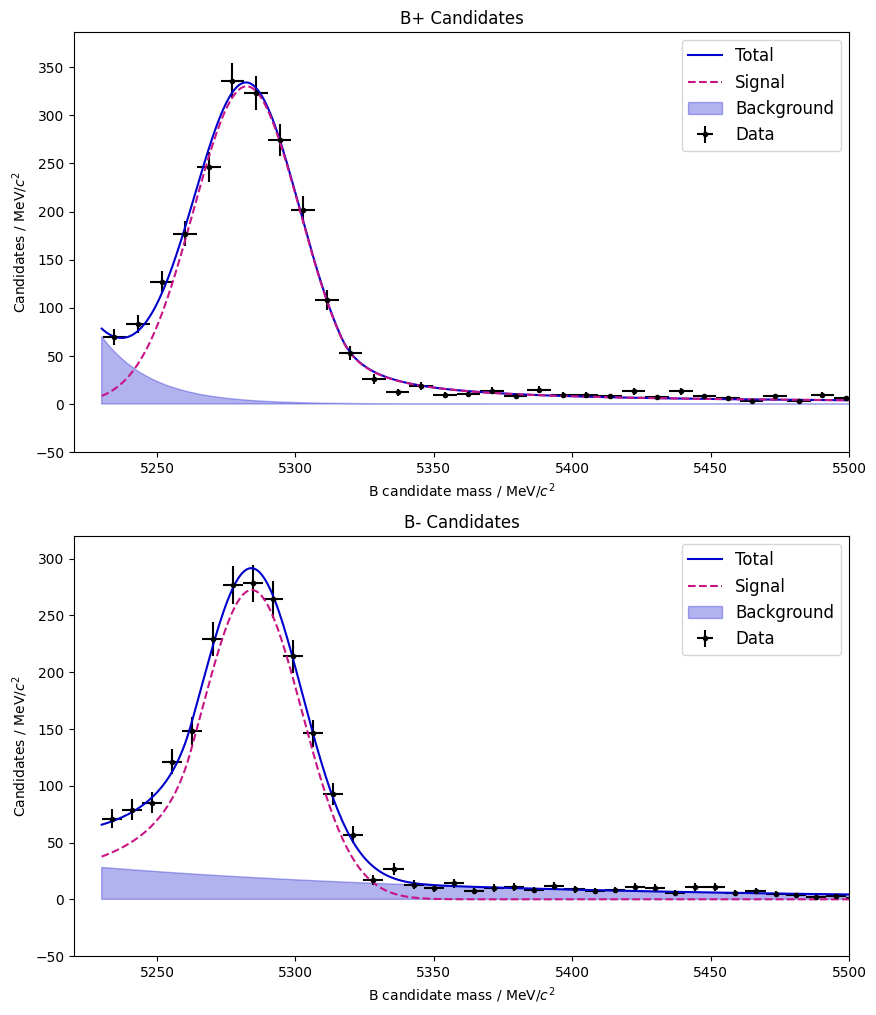

In [191]:
plt.style.use('default')

fig, ax = plt.subplots(2, 1, figsize=(10, 12))

plot_fit(ax[0], b_plus_data_Kmumu, plus_massc_rare, plus_total_modelc_rare, plus_signal_modelc_rare, plus_background_modelc_rare, plus_sig_yieldc_rare, plus_bkg_yieldc_rare)
ax[0].set_ylim(-50)
ax[0].set_xlim(right=5500)
ax[0].set_title('B+ Candidates')

plot_fit(ax[1], b_minus_data_Kmumu, minus_massc_rare, minus_total_modelc_rare, minus_signal_modelc_rare, minus_background_modelc_rare, minus_sig_yieldc_rare, minus_bkg_yieldc_rare)
ax[1].set_ylim(-50)
ax[1].set_xlim(right=5500)
ax[1].set_title('B- Candidates')
# plt.savefig(f'B_mass_fit_after_selection_{model}.png', transparent=True, bbox_inches='tight', dpi=300)

In [192]:
N_plus = plus_sig_yieldc_rare.value()
unc_plus = plus_resultc_rare.params[plus_sig_yieldc_rare]['hesse']['error']
N_minus = minus_sig_yieldc_rare.value()
unc_minus = minus_resultc_rare.params[minus_sig_yieldc_rare]['hesse']['error']

asymmetry_raw = (N_plus - N_minus) / (N_plus + N_minus)
unc = 2 * np.sqrt( (N_minus**2 * unc_plus**2 + N_plus**2 * unc_minus**2) ) / (N_plus + N_minus)**2

print(f"Raw Asymmetry: {asymmetry_raw:.4f} ± {unc:.4f}")

asymmetry = asymmetry_raw - asymmetry_norm
unc_asymmetry = np.sqrt(unc**2 + unc_norm**2)
print(f"Corrected Asymmetry: {asymmetry:.6f} ± {unc_asymmetry}")

Raw Asymmetry: 0.0887 ± 0.0228
Corrected Asymmetry: 0.073300 ± 0.022786920451544727


### Crystalball 2

In [88]:
def perform_zfit_plz_work(data_df, model_type, mass_range=(5230, 6000), a=-3, n=1):
    # 1. Define the Observable Space
    mass = zfit.Space('B invariant mass', mass_range)
    
    # 2. Define Shared Parameters
    # Initial guesses based on your plot: peak ~5280, width ~20
    mean = zfit.Parameter('mean', 5280, 5200, 6000)
    sigma = zfit.Parameter('sigma', 20, 5, 100)
    sig_yield = zfit.Parameter('sig_yield', len(data_df)//2, 0, len(data_df))
    
    # 3. Define Signal PDF based on input
    if model_type.lower() == 'gauss':
        signal_model = zfit.pdf.Gauss(obs=mass, mu=mean, sigma=sigma, extended=sig_yield)
    elif model_type.lower() == 'crystalball':
        # Crystal Ball adds 'alpha' (tail transition) and 'n' (tail power)
        alpha = zfit.Parameter('alpha', value = a, floating=False)
        n = zfit.Parameter('n', n, 0.0001, 10)
        signal_model = zfit.pdf.CrystalBall(obs=mass, mu=mean, sigma=sigma, 
                                            alpha=alpha, n=n, extended=sig_yield)
    elif model_type.lower() == 'doublegauss':
        mean = zfit.Parameter('mean', 5280, 5230, 6000)
        sigma1 = zfit.Parameter('sigma1', 15, 5, 50)
        sigma2 = zfit.Parameter('sigma2', 40, 20, 100)
        fraction = zfit.Parameter('fraction', 0.8, 0, 10) # % of events in the first Gaussian

        gauss1 = zfit.pdf.Gauss(obs=mass, mu=mean, sigma=sigma1)
        gauss2 = zfit.pdf.Gauss(obs=mass, mu=mean, sigma=sigma2)
        signal_model = zfit.pdf.SumPDF(pdfs=[gauss1, gauss2], fracs=fraction, extended=sig_yield)
    else:
        raise ValueError("Model type must be 'gauss', 'crystalball', or 'doublegauss'")

    # 4. Define Background Model (Exponential)
    exponent = zfit.Parameter('exponent', -0.001, -0.1, 0.1)
    bkg_yield = zfit.Parameter('bkg_yield', len(data_df)//2, 0, len(data_df))
    background_model = zfit.pdf.Exponential(obs=mass, lam=exponent, extended=bkg_yield)

    # 5. Combine and Fit
    total_model = zfit.pdf.SumPDF(pdfs=[signal_model, background_model])
    zdata = zfit.Data.from_pandas(data_df, mass)
    
    nll = zfit.loss.ExtendedUnbinnedNLL(model=total_model, data=zdata)
    minimizer = zfit.minimize.Minuit()
    result = minimizer.minimize(nll)

    # Calculate uncertainties
    result.hesse()

    # print(result)
    print('valid:', result.valid)
    print('-' * 30)
    print(f"Model type: {model_type}")
    print('-' * 30)

    n_b_mesons = sig_yield.value()
    unc = result.params[sig_yield]['hesse']['error']
    print(f"Number of B mesons: {n_b_mesons} ± {unc}")
    
    return result, total_model, signal_model, background_model, mass, sig_yield, bkg_yield

valid: True
------------------------------
Model type: crystalball
------------------------------
Number of B mesons: 1792.775282600617 ± 65.73788059716487
valid: True
------------------------------
Model type: crystalball
------------------------------
Number of B mesons: 1663.6365570395515 ± 63.320910136829475


C:\Users\cissi\AppData\Local\Temp\ipykernel_19956\477902239.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mass_in_range = data_df[data_df['B invariant mass'] >= float(mass.lower[0])]


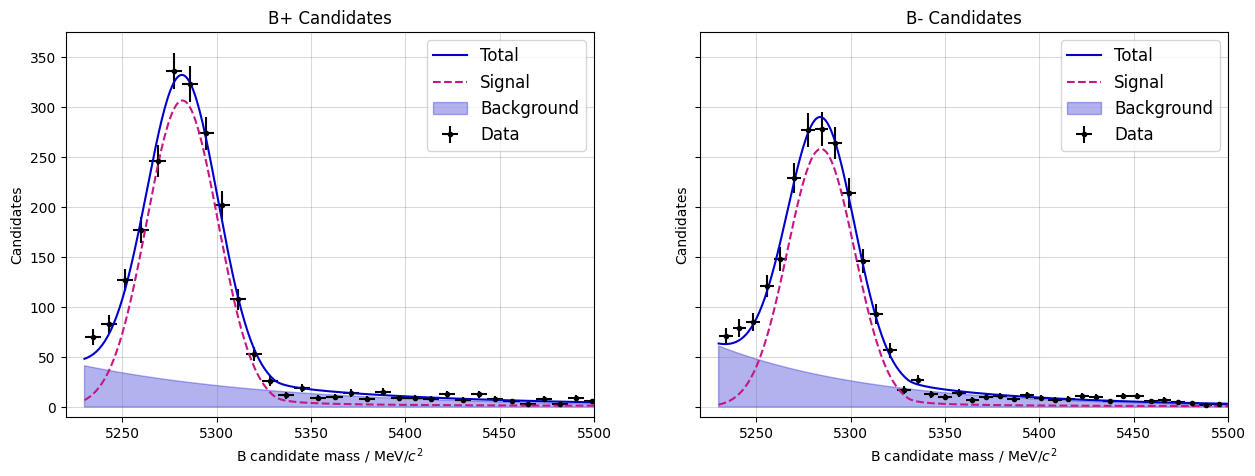

In [89]:
model = 'crystalball'

plus_resultc_rare, plus_total_modelc_rare, plus_signal_modelc_rare, plus_background_modelc_rare, plus_massc_rare, plus_sig_yieldc_rare, plus_bkg_yieldc_rare = perform_zfit_plz_work(
    b_plus_data_Kmumu, model_type=model, a=norm_resultc.params['alpha']['value'], n=norm_resultc.params['n']['value'])

minus_resultc_rare, minus_total_modelc_rare, minus_signal_modelc_rare, minus_background_modelc_rare, minus_massc_rare, minus_sig_yieldc_rare, minus_bkg_yieldc_rare = perform_zfit_plz_work(
    b_minus_data_Kmumu, model_type=model, a=norm_resultc.params['alpha']['value'], n=norm_resultc.params['n']['value'])

fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

plot_fit(ax[0], b_plus_data_Kmumu, plus_massc_rare, plus_total_modelc_rare, plus_signal_modelc_rare, plus_background_modelc_rare, plus_sig_yieldc_rare, plus_bkg_yieldc_rare)
# ax[0].set_ylim(-10, 400)
ax[0].set_xlim(right=5500)
ax[0].set_title('B+ Candidates')
ax[0].grid(color='gray', alpha=0.3)

plot_fit(ax[1], b_minus_data_Kmumu, minus_massc_rare, minus_total_modelc_rare, minus_signal_modelc_rare, minus_background_modelc_rare, minus_sig_yieldc_rare, minus_bkg_yieldc_rare)
ax[1].set_ylim(-10, 375)
ax[1].set_xlim(right=5500)
ax[1].set_title('B- Candidates')
ax[1].grid(color='gray', alpha=0.3)

In [79]:
#KS test
from scipy.stats import ks_1samp

def total_model_cdf(result, x):
    # 1. Define bounds and parameters
    low, high = 5230, 6000
    n_sig = result.params['sig_yield']['value']
    n_bkg = result.params['bkg_yield']['value']

    mu = result.params['mean']['value']
    sigma = result.params['sigma']['value']
    lam = result.params['exponent']['value']
    
    # 2. Gaussian Signal CDF (Normalized to the window)
    sig_raw = norm.cdf(x, loc=mu, scale=sigma)
    sig_lo = norm.cdf(low, loc=mu, scale=sigma)
    sig_hi = norm.cdf(high, loc=mu, scale=sigma)
    cdf_sig = (sig_raw - sig_lo) / (sig_hi - sig_lo)
    
    # 3. Exponential Background CDF (Normalized to the window)
    def exp_int(val): return (1/lam) * np.exp(lam * val)
    cdf_bkg = (exp_int(x) - exp_int(low)) / (exp_int(high) - exp_int(low))
    
    # 4. Weight by Yields
    f_sig = n_sig / (n_sig + n_bkg)
    return f_sig * cdf_sig + (1 - f_sig) * cdf_bkg

# Filter data to match the fit range
dataPlusc = b_plus_data_Kmumu['B invariant mass'][(b_plus_data_Kmumu['B invariant mass'] >= 5230) & 
                                              (b_plus_data_Kmumu['B invariant mass'] <= 6000)]
dataMinusc = b_minus_data_Kmumu['B invariant mass'][(b_minus_data_Kmumu['B invariant mass'] >= 5230) & 
                                              (b_minus_data_Kmumu['B invariant mass'] <= 6000)]

# Run the test
# We pass the function object 'total_model_cdf' without parentheses
print("B+ KS Test Results:")
statistic, p_value = ks_1samp(dataPlusc, lambda x: total_model_cdf(plus_resultc_rare, x))
print(f"KS Statistic: {statistic:.4f}")
print(f"p-value: {p_value:.6f}")

print('-'*30)
print("B- KS Test Results:")
statistic, p_value = ks_1samp(dataMinusc, lambda x: total_model_cdf(minus_resultc_rare, x))
print(f"KS Statistic: {statistic:.4f}")
print(f"p-value: {p_value:.6f}")

B+ KS Test Results:
KS Statistic: 0.0414
p-value: 0.000682
------------------------------
B- KS Test Results:
KS Statistic: 0.0349
p-value: 0.006184


In [103]:
asymmetry_norm_crys=asymmetry_norm_crys
unc_norm_crys=unc_norm_crys

N_plusc = plus_sig_yieldc_rare.value()
unc_plusc = plus_resultc_rare.params[plus_sig_yieldc_rare]['hesse']['error']
N_minusc = minus_sig_yieldc_rare.value()
unc_minusc = minus_resultc_rare.params[minus_sig_yieldc_rare]['hesse']['error']

asymmetry_rawc = (N_plusc - N_minusc) / (N_plusc + N_minusc)
uncc = 2 * np.sqrt( (N_minusc**2 * unc_plusc**2 + N_plusc**2 * unc_minusc**2) ) / (N_plusc + N_minusc)**2

print(f"Raw Asymmetry: {asymmetry_rawc:.4f} ± {uncc:.4f}")

asymmetry_c_final = asymmetry_rawc - asymmetry_norm_crys
unc_asymmetryc_final = np.sqrt(uncc**2 + unc_norm_crys**2)
print(f"Corrected Asymmetry: {asymmetry_c_final:.6f} ± {unc_asymmetryc_final:.6f}")

Raw Asymmetry: 0.0374 ± 0.0264
Corrected Asymmetry: 0.021862 ± 0.026426


In [ ]:
model = 'crystalball'

pulls_Bplus_c = pull_study(plus_total_modelc_rare, plus_resultc_rare.params, 
                         model_type=model, n_toys=150)

np.save('pull_Bplus_crystalball_results.npy', pulls_Bplus_c)

pulls_Bminus_c = pull_study(minus_total_modelc_rare, minus_resultc_rare.params, 
                         model_type=model, n_toys=150)

np.save('pull_Bminus_crystalball_results.npy', pulls_Bminus_c)

0
5281.912404316116 5281.864440715574 0.6574165376995647
0.07295770305671971
--------------------
1
5281.83298484414 5281.864440715574 0.5637602997377454
-0.05579653524570393
--------------------
2
5282.452022792705 5281.864440715574 0.5916229662310744
0.9931698238050193
--------------------
3
5282.297847614828 5281.864440715574 0.5987715388856668
0.7238268205941789
--------------------
4
5
5282.1832790190465 5281.864440715574 0.5638894035660541
0.5654270171700424
--------------------
6
5283.072696167268 5281.864440715574 0.6017691865706989
2.0078386840961633
--------------------
7
5281.575672790317 5281.864440715574 0.5628776988776886
-0.5130207251645084
--------------------
8
5281.991075986777 5281.864440715574 0.5915282350748688
0.21408153270440297
--------------------
9
5281.001640950995 5281.864440715574 0.5687707693184507
-1.516955179698975
--------------------
10
5281.64038930305 5281.864440715574 0.6312016614112315
-0.35496011215064527
--------------------
11
5282.164785220021 

In [75]:
pulls_Bplus_c = np.load('pull_Bplus_crystalball_results.npy')
pulls_Bminus_c = np.load('pull_Bminus_crystalball_results.npy')
print(f"Loaded {len(pulls_Bplus_c)} pulls for B+ and {len(pulls_Bminus_c)} pulls for B-")

Loaded 144 pulls for B+ and 149 pulls for B-


C:\Users\cissi\AppData\Local\Temp\ipykernel_5224\477902239.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mass_in_range = data_df[data_df['B invariant mass'] >= float(mass.lower[0])]


Pull mean: -0.05337519974418862, Pull sigma: 0.9619321483827447
Pull mean: -0.11762918924824595, Pull sigma: 0.9770221512451648


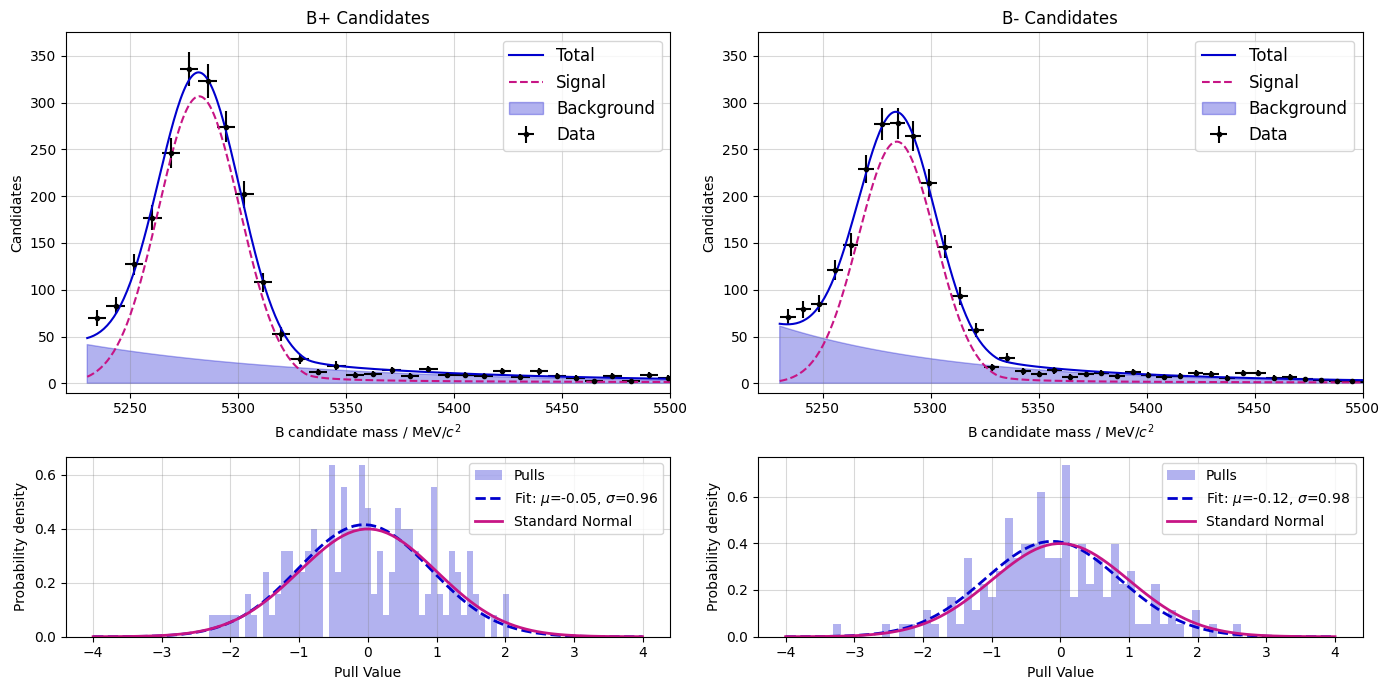

In [76]:
fig, ax = plt.subplots(2, 2, figsize=(14, 7),gridspec_kw={'height_ratios': [2, 1]})

plot_fit(ax[0, 0], b_plus_data_Kmumu, plus_massc_rare, plus_total_modelc_rare, plus_signal_modelc_rare, plus_background_modelc_rare, plus_sig_yieldc_rare, plus_bkg_yieldc_rare)
ax[0, 0].set_ylim(-10, 375)
ax[0, 0].set_xlim(right=5500)
ax[0, 0].set_title('B+ Candidates')
ax[0, 0].grid(color='gray', alpha=0.3)

ax[1, 0].hist(pulls_Bplus_c, bins=50, density=True, alpha=0.3, color=imperial_blue, label='Pulls')
(mu_fit_Bplus, sigma_fit_Bplus) = norm.fit(pulls_Bplus_c)

x = np.linspace(-4, 4, 100)
ax[1, 0].plot(x, norm.pdf(x, mu_fit_Bplus, sigma_fit_Bplus), '--', linewidth=2, color=imperial_blue,
         label=f'Fit: $\mu$={mu_fit_Bplus:.2f}, $\sigma$={sigma_fit_Bplus:.2f}')
ax[1, 0].plot(x, norm.pdf(x, 0, 1), '-', linewidth=2, color=imperial_pink, label='Standard Normal')
ax[1, 0].set_xlabel('Pull Value')
ax[1, 0].set_ylabel('Probability density')
# ax[1].set_title(f'Pull Distribution from Toy MC, model: Gaussian')
ax[1, 0].legend()
ax[1, 0].grid(color='gray', alpha=0.3)
# plt.savefig(f'pull_distribution_{model}.png', transparent=True, bbox_inches='tight', dpi=300)

plot_fit(ax[0, 1], b_minus_data_Kmumu, minus_massc_rare, minus_total_modelc_rare, minus_signal_modelc_rare, minus_background_modelc_rare, minus_sig_yieldc_rare, minus_bkg_yieldc_rare)
ax[0, 1].set_ylim(-10, 375)
ax[0, 1].set_xlim(right=5500)
ax[0, 1].set_title('B- Candidates')
ax[0, 1].grid(color='gray', alpha=0.3)

ax[1, 1].hist(pulls_Bminus_c, bins=50, density=True, alpha=0.3, color=imperial_blue, label='Pulls')
(mu_fit_Bminus, sigma_fit_Bminus) = norm.fit(pulls_Bminus_c)
ax[1, 1].plot(x, norm.pdf(x, mu_fit_Bminus, sigma_fit_Bminus), '--', linewidth=2, color=imperial_blue,
         label=f'Fit: $\mu$={mu_fit_Bminus:.2f}, $\sigma$={sigma_fit_Bminus:.2f}')
ax[1, 1].plot(x, norm.pdf(x, 0, 1), '-', linewidth=2, color=imperial_pink, label='Standard Normal')
ax[1, 1].set_xlabel('Pull Value')
ax[1, 1].set_ylabel('Probability density')
# ax[1].set_title(f'Pull Distribution from Toy MC, model: Gaussian')
ax[1, 1].legend()
ax[1, 1].grid(color='gray', alpha=0.3)

plt.tight_layout()

fig.savefig(f'BplusBminus_with_pull_distribution_{model}.png', transparent=True, bbox_inches='tight', dpi=300)

print(f"Pull mean: {mu_fit_Bplus}, Pull sigma: {sigma_fit_Bplus}")
print(f"Pull mean: {mu_fit_Bminus}, Pull sigma: {sigma_fit_Bminus}")

### Gaussian

valid: True
------------------------------
Model type: gauss
------------------------------
Number of B mesons: 1757.6583069093851 ± 55.16657260318055
valid: True
------------------------------
Model type: gauss
------------------------------
Number of B mesons: 1681.1042727951067 ± 65.3051674751934


C:\Users\cissi\AppData\Local\Temp\ipykernel_19956\477902239.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mass_in_range = data_df[data_df['B invariant mass'] >= float(mass.lower[0])]


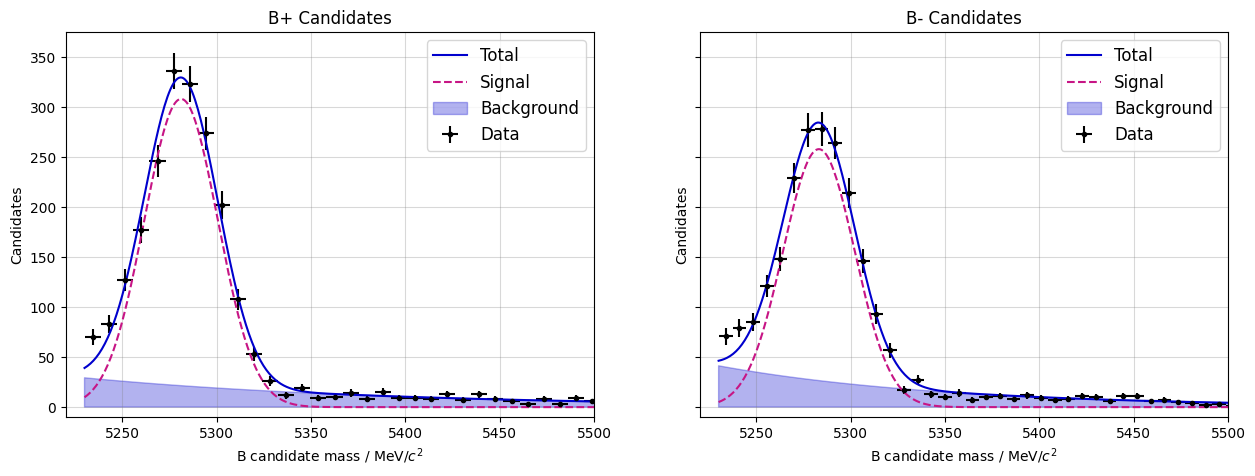

In [105]:
model = 'gauss'

plus_result, plus_total_model, plus_signal_model, plus_background_model, plus_mass, plus_sig_yield, plus_bkg_yield = perform_zfit(
    b_plus_data_Kmumu, model_type=model)

minus_result, minus_total_model, minus_signal_model, minus_background_model, minus_mass, minus_sig_yield, minus_bkg_yield = perform_zfit(
    b_minus_data_Kmumu, model_type=model)

fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

plot_fit(ax[0], b_plus_data_Kmumu, plus_mass, plus_total_model, plus_signal_model, plus_background_model, plus_sig_yield, plus_bkg_yield)
# ax[0].set_ylim(-10, 400)
ax[0].set_xlim(right=5500)
ax[0].set_title('B+ Candidates')
ax[0].grid(color='gray', alpha=0.3)

plot_fit(ax[1], b_minus_data_Kmumu, minus_mass, minus_total_model, minus_signal_model, minus_background_model, minus_sig_yield, minus_bkg_yield)
ax[1].set_ylim(-10, 375)
ax[1].set_xlim(right=5500)
ax[1].set_title('B- Candidates')
ax[1].grid(color='gray', alpha=0.3)

fig.savefig(f'BplusBminus_{model}.png', transparent=True, bbox_inches='tight', dpi=300)

In [74]:
#KS test
from scipy.stats import ks_1samp

def total_model_cdf(result, x):
    # 1. Define bounds and parameters
    low, high = 5230, 6000
    n_sig = result.params['sig_yield']['value']
    n_bkg = result.params['bkg_yield']['value']

    mu = result.params['mean']['value']
    sigma = result.params['sigma']['value']
    lam = result.params['exponent']['value']
    
    # 2. Gaussian Signal CDF (Normalized to the window)
    sig_raw = norm.cdf(x, loc=mu, scale=sigma)
    sig_lo = norm.cdf(low, loc=mu, scale=sigma)
    sig_hi = norm.cdf(high, loc=mu, scale=sigma)
    cdf_sig = (sig_raw - sig_lo) / (sig_hi - sig_lo)
    
    # 3. Exponential Background CDF (Normalized to the window)
    def exp_int(val): return (1/lam) * np.exp(lam * val)
    cdf_bkg = (exp_int(x) - exp_int(low)) / (exp_int(high) - exp_int(low))
    
    # 4. Weight by Yields
    f_sig = n_sig / (n_sig + n_bkg)
    return f_sig * cdf_sig + (1 - f_sig) * cdf_bkg

# Filter data to match the fit range
dataPlus = b_plus_data_Kmumu['B invariant mass'][(b_plus_data_Kmumu['B invariant mass'] >= 5230) & 
                                              (b_plus_data_Kmumu['B invariant mass'] <= 6000)]
dataMinus = b_minus_data_Kmumu['B invariant mass'][(b_minus_data_Kmumu['B invariant mass'] >= 5230) & 
                                              (b_minus_data_Kmumu['B invariant mass'] <= 6000)]

# Run the test
# We pass the function object 'total_model_cdf' without parentheses
print("B+ KS Test Results:")
statistic, p_value = ks_1samp(dataPlus, lambda x: total_model_cdf(plus_result, x))
print(f"KS Statistic: {statistic}")
print(f"p-value: {p_value}")

print('-'*30)
print("B- KS Test Results:")
statistic, p_value = ks_1samp(dataMinus, lambda x: total_model_cdf(minus_result, x))
print(f"KS Statistic: {statistic}")
print(f"p-value: {p_value}")


B+ KS Test Results:
KS Statistic: 0.016686670257594655
p-value: 0.53391513013143
------------------------------
B- KS Test Results:
KS Statistic: 0.02043499663342735
p-value: 0.2736934983057827


In [171]:
model = 'gauss'

pulls_Bplus = pull_study(plus_total_model, plus_result.params, 
                         model_type=model, n_toys=150)
np.save('pull_Bplus.npy', pulls_Bplus)

pulls_Bminus = pull_study(minus_total_model, minus_result.params, 
                         model_type=model, n_toys=150)
np.save('pull_Bminus.npy', pulls_Bminus)

0
5280.767914709979 5281.155134618803 0.5233576599102477
-0.7398762614654131
--------------------
1
5281.911769294318 5281.155134618803 0.5511287772987541
1.372881813982136
--------------------
2
5280.437228077573 5281.155134618803 0.5632897856833418
-1.274488832348218
--------------------
3
5280.227379854496 5281.155134618803 0.5819260411164162
-1.59428294792754
--------------------
4
5281.302735964391 5281.155134618803 0.5814573282496727
0.2538472531301149
--------------------
5
5281.032743707777 5281.155134618803 0.5575848315439002
-0.21950186608725156
--------------------
6
5281.712839704412 5281.155134618803 0.5458726634625967
1.021676158083158
--------------------
7
5280.119325214678 5281.155134618803 0.5823687105065686
-1.7786144506696755
--------------------
8
5280.6183667542855 5281.155134618803 0.5340907542868215
-1.0050124631605226
--------------------
9
5280.7748315304325 5281.155134618803 0.5560809211011534
-0.6838988246836059
--------------------
10
5280.882947451071 5281

In [2]:
import numpy as np
pulls_Bplus = np.load('pull_Bplus.npy')

# Verify the data
print(f"Loaded {len(pulls_Bplus)} pull values.")

pulls_Bminus = np.load('pull_Bminus.npy')
print(f"Loaded {len(pulls_Bminus)} pull values.")

Loaded 150 pull values.
Loaded 150 pull values.


C:\Users\cissi\AppData\Local\Temp\ipykernel_14732\477902239.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mass_in_range = data_df[data_df['B invariant mass'] >= float(mass.lower[0])]


Pull mean: -0.016922015870523915, Pull sigma: 1.0290637304052275
Pull mean: -0.05713783748557403, Pull sigma: 1.097604845833612


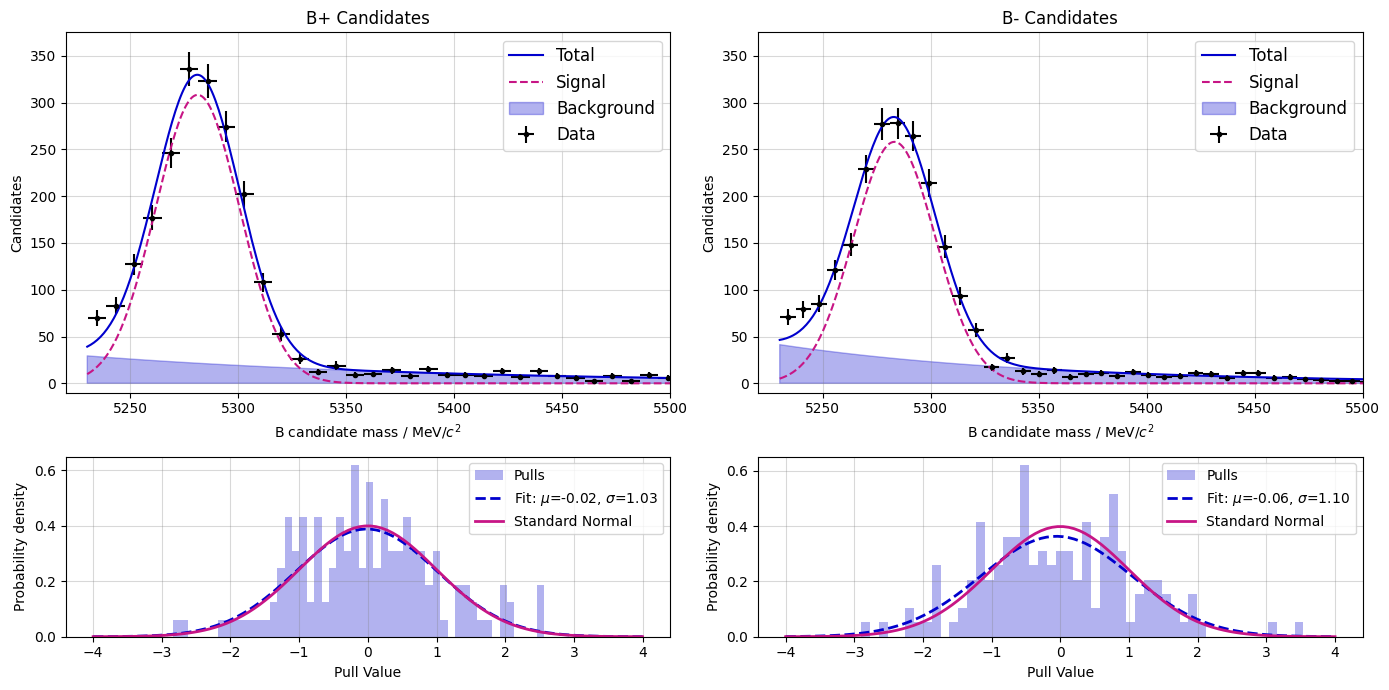

In [177]:
fig, ax = plt.subplots(2, 2, figsize=(14, 7),gridspec_kw={'height_ratios': [2, 1]})

plot_fit(ax[0, 0], b_plus_data_Kmumu, plus_mass, plus_total_model, plus_signal_model, plus_background_model, plus_sig_yield, plus_bkg_yield)
ax[0, 0].set_ylim(-10, 375)
ax[0, 0].set_xlim(right=5500)
ax[0, 0].set_title('B+ Candidates')
ax[0, 0].grid(color='gray', alpha=0.3)

ax[1, 0].hist(pulls_Bplus, bins=50, density=True, alpha=0.3, color=imperial_blue, label='Pulls')
(mu_fit_Bplus, sigma_fit_Bplus) = norm.fit(pulls_Bplus)

x = np.linspace(-4, 4, 100)
ax[1, 0].plot(x, norm.pdf(x, mu_fit_Bplus, sigma_fit_Bplus), '--', linewidth=2, color=imperial_blue,
         label=f'Fit: $\mu$={mu_fit_Bplus:.2f}, $\sigma$={sigma_fit_Bplus:.2f}')
ax[1, 0].plot(x, norm.pdf(x, 0, 1), '-', linewidth=2, color=imperial_pink, label='Standard Normal')
ax[1, 0].set_xlabel('Pull Value')
ax[1, 0].set_ylabel('Probability density')
# ax[1].set_title(f'Pull Distribution from Toy MC, model: Gaussian')
ax[1, 0].legend()
ax[1, 0].grid(color='gray', alpha=0.3)
# plt.savefig(f'pull_distribution_{model}.png', transparent=True, bbox_inches='tight', dpi=300)

plot_fit(ax[0, 1], b_minus_data_Kmumu, minus_mass, minus_total_model, minus_signal_model, minus_background_model, minus_sig_yield, minus_bkg_yield)
ax[0, 1].set_ylim(-10, 375)
ax[0, 1].set_xlim(right=5500)
ax[0, 1].set_title('B- Candidates')
ax[0, 1].grid(color='gray', alpha=0.3)

ax[1, 1].hist(pulls_Bminus, bins=50, density=True, alpha=0.3, color=imperial_blue, label='Pulls')
(mu_fit_Bminus, sigma_fit_Bminus) = norm.fit(pulls_Bminus)
ax[1, 1].plot(x, norm.pdf(x, mu_fit_Bminus, sigma_fit_Bminus), '--', linewidth=2, color=imperial_blue,
         label=f'Fit: $\mu$={mu_fit_Bminus:.2f}, $\sigma$={sigma_fit_Bminus:.2f}')
ax[1, 1].plot(x, norm.pdf(x, 0, 1), '-', linewidth=2, color=imperial_pink, label='Standard Normal')
ax[1, 1].set_xlabel('Pull Value')
ax[1, 1].set_ylabel('Probability density')
# ax[1].set_title(f'Pull Distribution from Toy MC, model: Gaussian')
ax[1, 1].legend()
ax[1, 1].grid(color='gray', alpha=0.3)

plt.tight_layout()

fig.savefig(f'BplusBminus_with_pull_distribution_{model}.png', transparent=True, bbox_inches='tight', dpi=300)

print(f"Pull mean: {mu_fit_Bplus}, Pull sigma: {sigma_fit_Bplus}")
print(f"Pull mean: {mu_fit_Bminus}, Pull sigma: {sigma_fit_Bminus}")

In [106]:
N_plus = plus_sig_yield.value()
unc_plus = plus_result.params[plus_sig_yield]['hesse']['error']
N_minus = minus_sig_yield.value()
unc_minus = minus_result.params[minus_sig_yield]['hesse']['error']

asymmetry_raw = (N_plus - N_minus) / (N_plus + N_minus)
unc = 2 * np.sqrt( (N_minus**2 * unc_plus**2 + N_plus**2 * unc_minus**2) ) / (N_plus + N_minus)**2

print(f"Raw Asymmetry: {asymmetry_raw:.4f} ± {unc:.4f}")

asymmetryg_final = asymmetry_raw - asymmetry_norm
unc_asymmetryg_final = np.sqrt(unc**2 + unc_norm**2)
print(f"Corrected Asymmetry: {asymmetryg_final:.6f} ± {unc_asymmetryg_final}")

Raw Asymmetry: 0.0223 ± 0.0250
Corrected Asymmetry: 0.006345 ± 0.02498591895636934


### Double Gaussian

valid: True
------------------------------
Model type: doublegauss
------------------------------
Number of B mesons: 1304.8110276851746 ± 151.4499226773955
valid: True
------------------------------
Model type: doublegauss
------------------------------
Number of B mesons: 1714.4222517344676 ± 69.57448055372456


C:\Users\cissi\AppData\Local\Temp\ipykernel_3140\3133212847.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mass_in_range = data_df[data_df['B invariant mass'] >= float(mass.lower[0])]


Text(0.5, 1.0, 'B- Candidates')

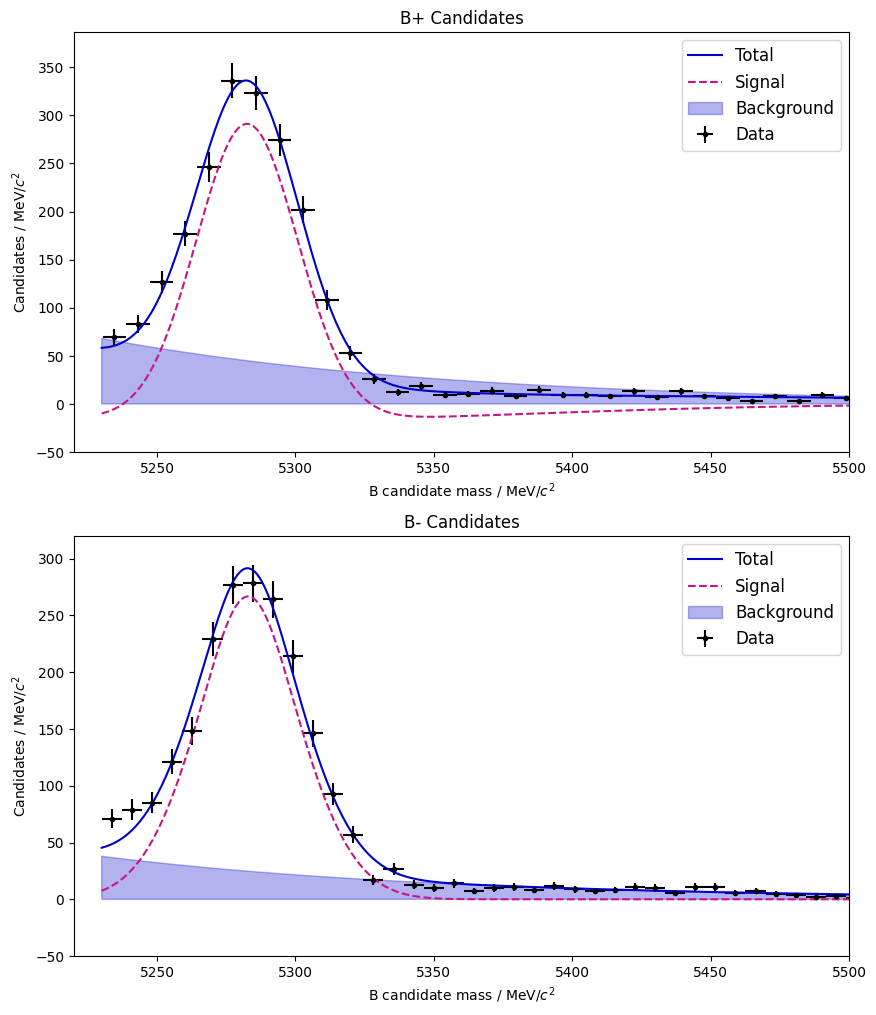

In [199]:
model = 'doublegauss'

plus_result, plus_total_model, plus_signal_model, plus_background_model, plus_mass, plus_sig_yield, plus_bkg_yield = perform_zfit(
    b_plus_data_Kmumu, model_type=model)

minus_result, minus_total_model, minus_signal_model, minus_background_model, minus_mass, minus_sig_yield, minus_bkg_yield = perform_zfit(
    b_minus_data_Kmumu, model_type=model)

fig, ax = plt.subplots(2, 1, figsize=(10, 12))

plot_fit(ax[0], b_plus_data_Kmumu, plus_mass, plus_total_model, plus_signal_model, plus_background_model, plus_sig_yield, plus_bkg_yield)
ax[0].set_ylim(-50)
ax[0].set_xlim(right=5500)
ax[0].set_title('B+ Candidates')

plot_fit(ax[1], b_minus_data_Kmumu, minus_mass, minus_total_model, minus_signal_model, minus_background_model, minus_sig_yield, minus_bkg_yield)
ax[1].set_ylim(-50)
ax[1].set_xlim(right=5500)
ax[1].set_title('B- Candidates')

In [200]:
N_plus = plus_sig_yield.value()
unc_plus = plus_result.params[plus_sig_yield]['hesse']['error']
N_minus = minus_sig_yield.value()
unc_minus = minus_result.params[minus_sig_yield]['hesse']['error']

asymmetry_raw = (N_plus - N_minus) / (N_plus + N_minus)
unc = 2 * np.sqrt( (N_minus**2 * unc_plus**2 + N_plus**2 * unc_minus**2) ) / (N_plus + N_minus)**2

print(f"Raw Asymmetry: {asymmetry_raw:.4f} ± {unc:.4f}")

asymmetry = asymmetry_raw - asymmetry_norm
unc_asymmetry = np.sqrt(unc**2 + unc_norm**2)
print(f"Corrected Asymmetry: {asymmetry:.6f} ± {unc_asymmetry}")

Raw Asymmetry: -0.1357 ± 0.0603
Corrected Asymmetry: -0.151040 ± 0.060358986773399605


# Task 8
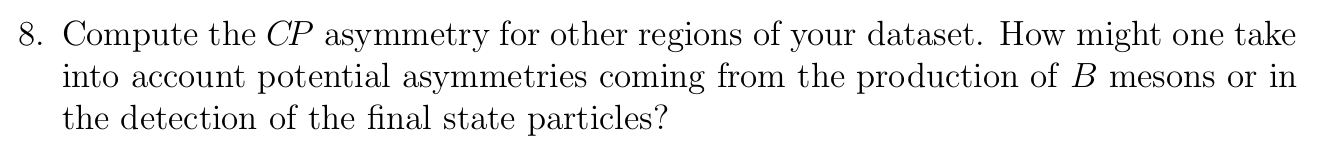

In [ ]:
plt.style.use('dark_background')
model = 'gauss'

plus_result, plus_total_model, plus_signal_model, plus_background_model, plus_mass, plus_sig_yield, plus_bkg_yield = perform_zfit(
    b_plus_data_Kmumu, model_type=model)

minus_result, minus_total_model, minus_signal_model, minus_background_model, minus_mass, minus_sig_yield, minus_bkg_yield = perform_zfit(
    b_minus_data_Kmumu, model_type=model)

fig, ax = plt.subplots(2, 1, figsize=(10, 12))

plot_fit(ax[0], b_plus_data_Kmumu, plus_mass, plus_total_model, plus_signal_model, plus_background_model, plus_sig_yield, plus_bkg_yield)
ax[0].set_ylim(-50)
ax[0].set_title('B+ Candidates')

plot_fit(ax[1], b_minus_data_Kmumu, minus_mass, minus_total_model, minus_signal_model, minus_background_model, minus_sig_yield, minus_bkg_yield)
ax[1].set_ylim(-50)
ax[1].set_title('B- Candidates')

In [ ]:
N_plus = plus_sig_yield.value()
unc_plus = plus_result.params[plus_sig_yield]['hesse']['error']
N_minus = minus_sig_yield.value()
unc_minus = minus_result.params[minus_sig_yield]['hesse']['error']

asymmetry_raw = (N_plus - N_minus) / (N_plus + N_minus)
unc = 2 * np.sqrt( (N_minus**2 * unc_plus**2 + N_plus**2 * unc_minus**2) ) / (N_plus + N_minus)**2

print(f"Raw Asymmetry: {asymmetry_raw:.4f} ± {unc:.4f}")

asymmetry = asymmetry_raw - asymmetry_norm
unc_asymmetry = np.sqrt(unc**2 + unc_norm**2)
print(f"Corrected Asymmetry: {asymmetry:.6f} ± {unc_asymmetry}")

# Other

In [ ]:
# header = all_data.columns.tolist()

# n = 140

# fig, ax = plt.subplots(int(n/4), 4, figsize=(15, int(60/140 * n)))

# axes = ax.flatten()

# for i in range (n):
#     axes[i].hist(all_data[header[i]], bins=30, edgecolor='black')

#     axes[i].set_title(f'{header[i]}', fontsize=10)


# # Edit tick parameters on each axis
#     axes[i].tick_params(labelsize=10, direction='in', top=True, right=True, which='both')


# # Save your plot
# plt.tight_layout()
# plt.show()

In [258]:
all_data['B assumed particle type'].value_counts().head(20)


B assumed particle type
 521    1514021
-521    1470568
Name: count, dtype: int64

In [250]:
all_data.columns.tolist()

['B decay vertex x position',
 'B decay vertex y position',
 'B decay vertex z position',
 'B decay vertex fit chi2',
 'B impact parameter wrt primary vertex',
 'B impact parameter chi2 wrt primary vertex',
 'B flight distance wrt primary vertex',
 'B flight distance chi2 wrt primary vertex',
 'B cos(angle) between line-of-flight and momentum',
 'B magnitude of momentum',
 'B magnitude of momentum transverse to beam',
 'B 4-momentum energy component',
 'B 4-momentum x component',
 'B 4-momentum y component',
 'B 4-momentum z component',
 'B invariant mass',
 'B assumed particle type',
 'B lifetime',
 'Isolation: Charged cone angle',
 'Isolation: Charged cone number of particles contained',
 'Isolation: Charged cone eta difference between cone momentum and B',
 'Isolation: Charged cone phi difference between cone momentum and B',
 'Isolation: Charged cone ratio of B momentum and B+cone momentum all in transverse plane',
 'Isolation: Charged cone 4-momentum of max-PT object energy compon

In [410]:
# Load the samesign dataset
with open(r"C:\Users\cissi\OneDrive - Imperial College London\Y3Lab\C1_notebooks\C1\McCann, Michael A's files - 3rd Year Labs - Particle Physics Data\LHCb\rapidsim_Kmumu.pkl", 'rb') as infile:
  sim_Kmumu = pickle.load(infile)

with open(r"C:\Users\cissi\OneDrive - Imperial College London\Y3Lab\C1_notebooks\C1\McCann, Michael A's files - 3rd Year Labs - Particle Physics Data\LHCb\rapidsim_JpsiK.pkl", 'rb') as infile:
  sim_JpsiK = pickle.load(infile)

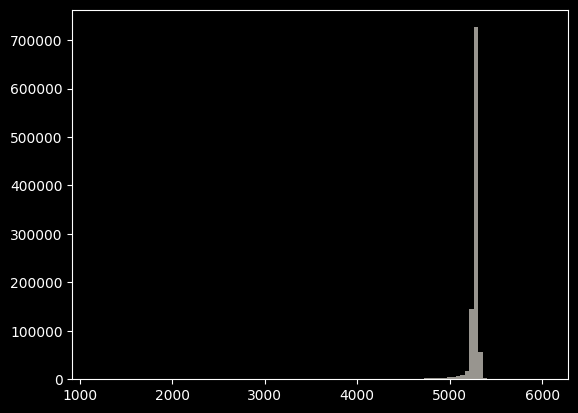

(array([2.00000e+00, 1.00000e+00, 1.00000e+00, 4.00000e+00, 2.00000e+00,
        5.00000e+00, 5.00000e+00, 4.00000e+00, 3.00000e+00, 2.00000e+00,
        8.00000e+00, 6.00000e+00, 2.00000e+00, 1.10000e+01, 9.00000e+00,
        1.20000e+01, 1.20000e+01, 1.60000e+01, 2.10000e+01, 2.00000e+01,
        2.20000e+01, 2.80000e+01, 2.40000e+01, 4.40000e+01, 2.60000e+01,
        3.90000e+01, 4.40000e+01, 3.30000e+01, 4.50000e+01, 5.20000e+01,
        5.70000e+01, 6.20000e+01, 6.80000e+01, 6.40000e+01, 9.30000e+01,
        6.90000e+01, 7.20000e+01, 1.16000e+02, 1.14000e+02, 9.90000e+01,
        1.33000e+02, 1.51000e+02, 1.38000e+02, 1.53000e+02, 1.68000e+02,
        1.78000e+02, 2.07000e+02, 2.16000e+02, 2.31000e+02, 2.75000e+02,
        2.76000e+02, 2.62000e+02, 3.31000e+02, 3.45000e+02, 3.79000e+02,
        4.16000e+02, 4.04000e+02, 4.59000e+02, 4.71000e+02, 5.30000e+02,
        5.60000e+02, 5.74000e+02, 6.70000e+02, 6.70000e+02, 7.72000e+02,
        8.35000e+02, 8.86000e+02, 9.80000e+02, 1.07

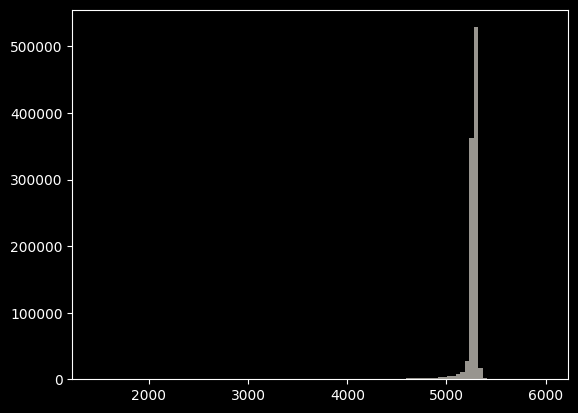

In [412]:
plt.hist(sim_Kmumu['B invariant mass'], bins=100, alpha=0.6, color = 'floralwhite', label = 'Kmumu Simulation')
plt.show()
plt.hist(sim_JpsiK['B invariant mass'], bins=100, alpha=0.6, color = 'floralwhite', label = 'JpsiK Simulation')

# Extension 1

In [ ]:
# selected_data['q squared (GeV/c^2)^2'] = (selected_data['dimuon-system invariant mass'] / 1000) ** 2
# selected_data['q squared (GeV/c^2)^2'].describe()

#asymmetry_rawc = asymmetry_rawc - asymmetry_norm_crys
#asymmetry = asymmetry_raw - asymmetry_norm

C:\Users\cissi\AppData\Local\Temp\ipykernel_5224\2059040400.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_data['q squared (GeV/c^2)^2'] = (selected_data['dimuon-system invariant mass'] / 1000) ** 2


count    1.854610e+06
mean     9.832550e+00
std      1.176587e+00
min      8.022439e-02
25%      9.543731e+00
50%      9.610828e+00
75%      9.678473e+00
max      3.368282e+01
Name: q squared (GeV/c^2)^2, dtype: float64

In [107]:
print("CBF:")
print(f"Corrected Asymmetry: {asymmetry_c_final:.6f} ± {unc_asymmetryc_final:.6f}")
print("Gauss:")
print(f"Corrected Asymmetry: {asymmetryg_final:.6f} ± {unc_asymmetryg_final}")

CBF:
Corrected Asymmetry: 0.021862 ± 0.026426
Gauss:
Corrected Asymmetry: 0.006345 ± 0.02498591895636934


In [108]:
b_plus_data_Kmumu['q squared (GeV/c^2)^2'] = (b_plus_data_Kmumu['dimuon-system invariant mass'] / 1000) ** 2
b_plus_data_Kmumu['q squared (GeV/c^2)^2'].describe()
b_minus_data_Kmumu['q squared (GeV/c^2)^2'] = (b_minus_data_Kmumu['dimuon-system invariant mass'] / 1000) ** 2
b_minus_data_Kmumu['q squared (GeV/c^2)^2'].describe()

jpsi_q2_low = ((mu_jpsi - 100) / 1000) ** 2
jpsi_q2_high = ((mu_jpsi + 100) / 1000) ** 2

psi2s_q2_low = ((mu_psi2s - 100) / 1000) ** 2
psi2s_q2_high = ((mu_psi2s + 100) / 1000) ** 2

C:\Users\cissi\AppData\Local\Temp\ipykernel_19956\2749797647.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  b_plus_data_Kmumu['q squared (GeV/c^2)^2'] = (b_plus_data_Kmumu['dimuon-system invariant mass'] / 1000) ** 2
C:\Users\cissi\AppData\Local\Temp\ipykernel_19956\2749797647.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  b_minus_data_Kmumu['q squared (GeV/c^2)^2'] = (b_minus_data_Kmumu['dimuon-system invariant mass'] / 1000) ** 2


75% at around 9.678473, corresponding to $J/\psi$ 
You must remove resonance regions, because:
- they are long-distance dominated
- CP asymmetry is not described by rare-decay theory
- they will completely bias your $A_{CP}(q^2)$

### Gaussian

In [124]:
# Region 1: 0.1 to J/psi_low (e.g., 3 bins = 4 edges)
edges_low = np.linspace(0.1, jpsi_q2_low, 5)

# Region 2: J/psi_high to psi2s_low (e.g., 2 bins = 3 edges)
edges_mid = np.linspace(jpsi_q2_high, psi2s_q2_low, 3)

# Region 3: psi2s_high to 22 (e.g., 3 bins = 4 edges)
edges_high = np.linspace(psi2s_q2_high, 22, 5)

# Create the list of intervals manually to ensure no 'zero-width' bins
intervals = []
for i in range(len(edges_low)-1):
    intervals.append((edges_low[i], edges_low[i+1]))
for i in range(len(edges_mid)-1):
    intervals.append((edges_mid[i], edges_mid[i+1]))
for i in range(len(edges_high)-1):
    intervals.append((edges_high[i], edges_high[i+1]))

acp = []
acp_err = []
bin_centers = []
xerr = []

for low, high in intervals:
    b_plus = b_plus_data_Kmumu[(b_plus_data_Kmumu['q squared (GeV/c^2)^2'] >= low) & 
                              (b_plus_data_Kmumu['q squared (GeV/c^2)^2'] < high)]
    b_minus = b_minus_data_Kmumu[(b_minus_data_Kmumu['q squared (GeV/c^2)^2'] >= low) & 
                                (b_minus_data_Kmumu['q squared (GeV/c^2)^2'] < high)]
    plus_result, plus_total_model, plus_signal_model, plus_background_model, plus_mass, plus_sig_yield, plus_bkg_yield = perform_zfit(b_plus, model_type='gauss')
    minus_result, minus_total_model, minus_signal_model, minus_background_model, minus_mass, minus_sig_yield, minus_bkg_yield = perform_zfit(b_minus, model_type='gauss')

    if (plus_result.valid) & (minus_result.valid):

        N_plus = plus_sig_yield.value()
        unc_plus = plus_result.params[plus_sig_yield]['hesse']['error']
        N_minus = minus_sig_yield.value()
        unc_minus = minus_result.params[minus_sig_yield]['hesse']['error']

        asymmetry_raw = (N_plus - N_minus) / (N_plus + N_minus)
        unc = 2 * np.sqrt( (N_minus**2 * unc_plus**2 + N_plus**2 * unc_minus**2) ) / (N_plus + N_minus)**2

        print(f"Raw Asymmetry: {asymmetry_raw:.4f} ± {unc:.4f}")

        asymmetry = asymmetry_raw - asymmetry_norm
        unc_asymmetry = np.sqrt(unc**2 + unc_norm**2)
        print(f"Corrected Asymmetry: {asymmetry:.6f} ± {unc_asymmetry}")
        acp.append(asymmetry)
        acp_err.append(unc_asymmetry)
        bin_centers.append(0.5 * (low + high))
        xerr.append(0.5 * (high - low))
    else:
        continue

valid: True
------------------------------
Model type: gauss
------------------------------
Number of B mesons: 69.99530228974471 ± 8.360049225399267
valid: False
------------------------------
Model type: gauss
------------------------------
Number of B mesons: 64.0014640121232 ± 1.8535079377306614
valid: True
------------------------------
Model type: gauss
------------------------------
Number of B mesons: 137.0168482952988 ± 12.863777300143187
valid: True
------------------------------
Model type: gauss
------------------------------
Number of B mesons: 129.11996422120745 ± 13.763127794338176
Raw Asymmetry: 0.0297 ± 0.0710
Corrected Asymmetry: 0.013755 ± 0.07096850473711099
valid: True
------------------------------
Model type: gauss
------------------------------
Number of B mesons: 212.9914625479665 ± 18.22801941609819
valid: True
------------------------------
Model type: gauss
------------------------------
Number of B mesons: 192.80295620646243 ± 17.95174812516862
Raw Asymmetr

In [ ]:
acp = np.array(acp)
acp_err = np.array(acp_err)

weights = 1 / acp_err**2

mean_acp = np.sum(weights * acp) / np.sum(weights)
mean_acp_err = np.sqrt(1 / np.sum(weights))

print(f"Weighted mean ACP: {mean_acp:.6f} ± {mean_acp_err:.6f}")


Weighted mean ACP: 0.003684 ± 0.024320
Weighted mean ACP: 0.003684 ± 0.024320


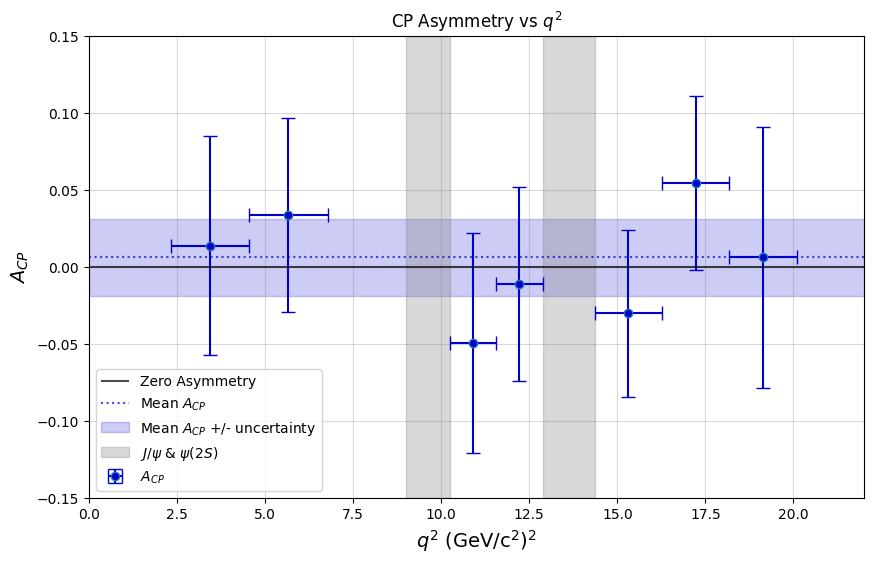

In [144]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.errorbar(bin_centers, acp, xerr=xerr, yerr=acp_err, fmt='o', markerfacecolor=imperial_blue, ecolor=imperial_blue, capsize=5, label='$A_{CP}$')
ax.hlines(0, xmin=0, xmax=22.0, colors='black', alpha = 0.7, label='Zero Asymmetry')
ax.hlines(asymmetryg_final, xmin=0, xmax=22.0, colors=imperial_blue, alpha = 0.7, linestyles=':', label='Mean $A_{CP}$')

ax.fill_between(
    np.linspace(0, 22.0, 250),
    asymmetryg_final - unc_asymmetryg_final,
    asymmetryg_final + unc_asymmetryg_final,
    color=imperial_blue,
    alpha=0.2,
    label='Mean $A_{CP}$ +/- uncertainty'
)

ax.fill_betweenx([-0.15, 0.15], jpsi_q2_low, jpsi_q2_high, color='grey', alpha = 0.3, label='$J/\\psi$ & $\\psi(2S)$')
ax.fill_betweenx([-0.15, 0.15], psi2s_q2_low, psi2s_q2_high, color='grey', alpha = 0.3)

ax.legend()
ax.set_xlabel('$q^{2}$ (GeV/c$^{2}$)$^{2}$', fontsize=14)
ax.set_ylabel('$A_{CP}$', fontsize=14)
ax.set_title('CP Asymmetry vs $q^{2}$')
ax.set_xlim(0, 22.0)
ax.set_ylim(-0.15, 0.15)
ax.grid(color='gray', alpha=0.3)
fig.savefig('ACP_vs_q2.png', transparent=True, bbox_inches='tight', dpi=300)

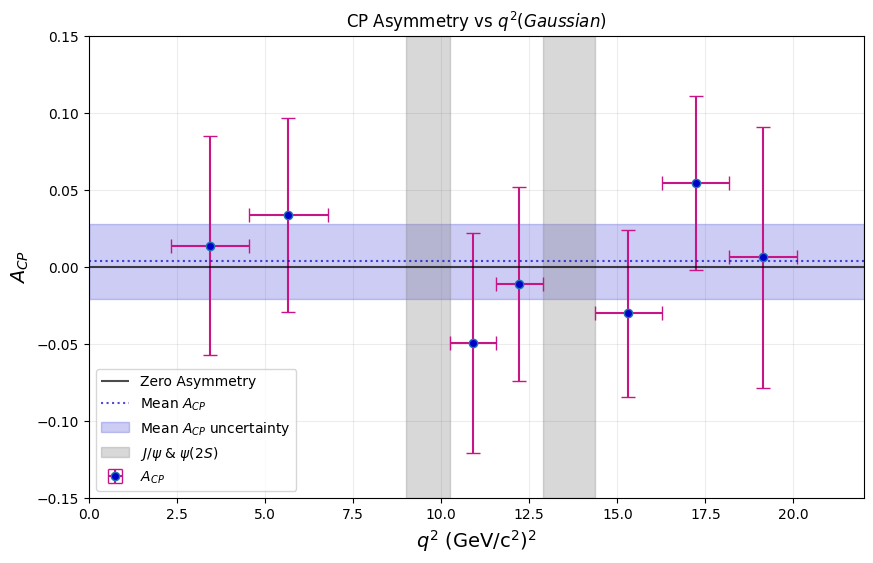

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.errorbar(bin_centers, acp, xerr=xerr, yerr=acp_err, fmt='o', markerfacecolor=imperial_blue, ecolor=imperial_pink, capsize=5, label='$A_{CP}$')
ax.hlines(0, xmin=0, xmax=22.0, colors='black', alpha = 0.7, label='Zero Asymmetry')
ax.hlines(mean_acp, xmin=0, xmax=22.0, colors=imperial_blue, alpha = 0.7, linestyles=':', label='Mean $A_{CP}$')

ax.fill_between(
    np.linspace(0, 22.0, 250),
    mean_acp - mean_acp_err,
    mean_acp + mean_acp_err,
    color=imperial_blue,
    alpha=0.2,
    label='Mean $A_{CP}$ uncertainty'
)

ax.fill_betweenx([-0.15, 0.15], jpsi_q2_low, jpsi_q2_high, color='grey', alpha = 0.3, label='$J/\\psi$ & $\\psi(2S)$')
ax.fill_betweenx([-0.15, 0.15], psi2s_q2_low, psi2s_q2_high, color='grey', alpha = 0.3)

ax.legend()
ax.set_xlabel('$q^{2}$ (GeV/c$^{2}$)$^{2}$', fontsize=14)
ax.set_ylabel('$A_{CP}$', fontsize=14)
ax.set_title('CP Asymmetry vs $q^{2} (Gaussian)$')
ax.set_xlim(0, 22.0)
ax.set_ylim(-0.15, 0.15)
ax.grid(color='gray', alpha=0.15)
fig.savefig('ACP_vs_q2.png', transparent=True, bbox_inches='tight', dpi=300)

### CBF

In [186]:
# Region 1: 0.1 to J/psi_low (e.g., 3 bins = 4 edges)
edges_low = np.linspace(0.1, jpsi_q2_low, 6)

# Region 2: J/psi_high to psi2s_low (e.g., 2 bins = 3 edges)
edges_mid = np.linspace(jpsi_q2_high, psi2s_q2_low, 3)

# Region 3: psi2s_high to 22 (e.g., 3 bins = 4 edges)
edges_high = np.linspace(psi2s_q2_high, 22, 5)

# Create the list of intervals manually to ensure no 'zero-width' bins
intervals = []
for i in range(len(edges_low)-1):
    intervals.append((edges_low[i], edges_low[i+1]))
for i in range(len(edges_mid)-1):
    intervals.append((edges_mid[i], edges_mid[i+1]))
for i in range(len(edges_high)-1):
    intervals.append((edges_high[i], edges_high[i+1]))

acpc = []
acp_errc = []
bin_centersc = []
xerrc = []

for low, high in intervals:
    b_plus = b_plus_data_Kmumu[(b_plus_data_Kmumu['q squared (GeV/c^2)^2'] >= low) & 
                              (b_plus_data_Kmumu['q squared (GeV/c^2)^2'] < high)]
    b_minus = b_minus_data_Kmumu[(b_minus_data_Kmumu['q squared (GeV/c^2)^2'] >= low) & 
                                (b_minus_data_Kmumu['q squared (GeV/c^2)^2'] < high)]
    plus_result, plus_total_model, plus_signal_model, plus_background_model, plus_mass, plus_sig_yield, plus_bkg_yield = perform_zfit(b_plus, model_type='crystalball')
    minus_result, minus_total_model, minus_signal_model, minus_background_model, minus_mass, minus_sig_yield, minus_bkg_yield = perform_zfit(b_minus, model_type='crystalball')

    if (plus_result.valid) & (minus_result.valid):

        N_plus = plus_sig_yield.value()
        unc_plus = plus_result.params[plus_sig_yield]['hesse']['error']
        N_minus = minus_sig_yield.value()
        unc_minus = minus_result.params[minus_sig_yield]['hesse']['error']

        asymmetry_raw = (N_plus - N_minus) / (N_plus + N_minus)
        unc = 2 * np.sqrt( (N_minus**2 * unc_plus**2 + N_plus**2 * unc_minus**2) ) / (N_plus + N_minus)**2

        print(f"Raw Asymmetry: {asymmetry_raw:.4f} ± {unc:.4f}")

        asymmetry = asymmetry_raw - asymmetry_norm_crys
        unc_asymmetry = np.sqrt(unc**2 + unc_norm**2)
        print(f"Corrected Asymmetry: {asymmetry:.6f} ± {unc_asymmetry}")
        acpc.append(asymmetry)
        acp_errc.append(unc_asymmetry)
        bin_centersc.append(0.5 * (low + high))
        xerrc.append(0.5 * (high - low))
    else:
        continue

valid: True
------------------------------
Model type: crystalball
------------------------------
Number of B mesons: 42.08379404848808 ± 1.5957816490990604
valid: True
------------------------------
Model type: crystalball
------------------------------
Number of B mesons: 48.01866107392469 ± 3.026515171066362
Raw Asymmetry: -0.0659 ± 0.0366
Corrected Asymmetry: -0.081368 ± 0.0366368227865038
valid: True
------------------------------
Model type: crystalball
------------------------------
Number of B mesons: 94.83818268494291 ± 12.524435070671895
valid: True
------------------------------
Model type: crystalball
------------------------------
Number of B mesons: 98.11181933139856 ± 10.761275270145434
Raw Asymmetry: -0.0170 ± 0.0858
Corrected Asymmetry: -0.032466 ± 0.08581840919012404
valid: True
------------------------------
Model type: crystalball
------------------------------
Number of B mesons: 169.08075778638633 ± 14.938683428718436
valid: True
------------------------------
Mod

In [187]:
acpc = np.array(acpc)
acp_errc = np.array(acp_errc)

weightsc = 1 / acp_errc**2

mean_acpc = np.sum(weightsc * acpc) / np.sum(weightsc)
mean_acp_errc = np.sqrt(1 / np.sum(weightsc))

print(f"Weighted mean ACP: {mean_acpc:.6f} ± {mean_acp_errc:.6f}")

Weighted mean ACP: 0.009733 ± 0.020921


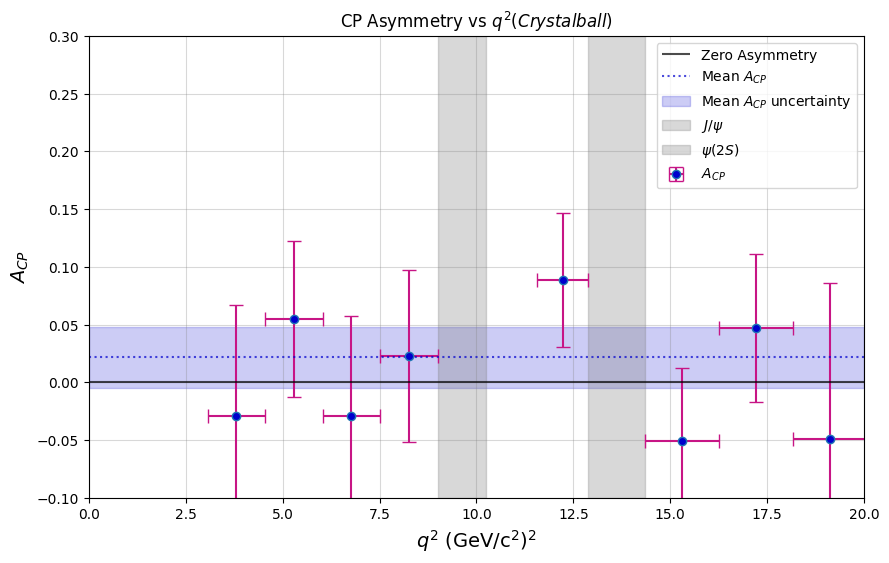

In [172]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.errorbar(bin_centersc, acpc, xerr=xerrc, yerr=acp_errc, fmt='o', markerfacecolor=imperial_blue, ecolor=imperial_pink, capsize=5, label='$A_{CP}$')
ax.hlines(0, xmin=0, xmax=20.0, colors='black', alpha = 0.7, label='Zero Asymmetry')
ax.hlines(asymmetry_c_final, xmin=0, xmax=20.0, colors=imperial_blue, alpha = 0.7, linestyles=':', label='Mean $A_{CP}$')

ax.fill_between(
    np.linspace(0, 20.0, 200),
    asymmetry_c_final - unc_asymmetryc_final,
    asymmetry_c_final + unc_asymmetryc_final,
    color=imperial_blue,
    alpha=0.2,
    label='Mean $A_{CP}$ uncertainty'
)

ax.fill_betweenx([-0.1, 0.3], jpsi_q2_low, jpsi_q2_high, color='grey', alpha = 0.3, label='$J/\\psi$')
ax.fill_betweenx([-0.1, 0.3], psi2s_q2_low, psi2s_q2_high, color='grey', alpha = 0.3, label='$\\psi(2S)$')

ax.legend(loc='upper right')
ax.set_xlabel('$q^{2}$ (GeV/c$^{2}$)$^{2}$', fontsize=14)
ax.set_ylabel('$A_{CP}$', fontsize=14)
ax.set_title('CP Asymmetry vs $q^{2} (Crystalball)$')
ax.set_xlim(0, 20.0)
ax.set_ylim(-0.1, 0.3)
ax.grid(color='gray', alpha=0.3)
# fig.savefig('ACP_vs_q2.png', transparent=True, bbox_inches='tight', dpi=300)

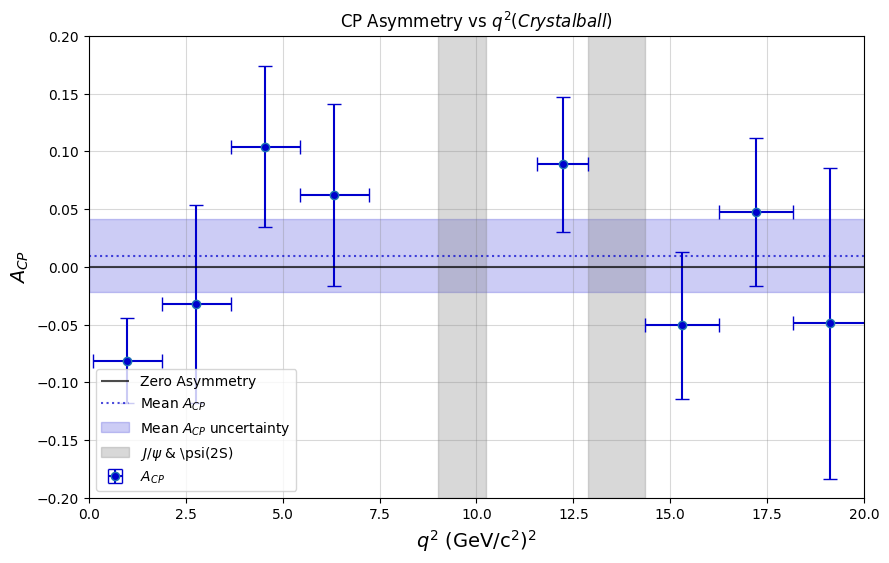

In [194]:
mean_acpc = 0.009733
mean_acp_errc = 0.020921

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.errorbar(bin_centersc, acpc, xerr=xerrc, yerr=acp_errc, fmt='o', markerfacecolor=imperial_blue, ecolor=imperial_blue, capsize=5, label='$A_{CP}$')
ax.hlines(0, xmin=0, xmax=20.0, colors='black', alpha = 0.7, label='Zero Asymmetry')
ax.hlines(mean_acpc, xmin=0, xmax=20.0, colors=imperial_blue, alpha = 0.7, linestyles=':', label='Mean $A_{CP}$')

ax.fill_between(
    np.linspace(0, 20.0, 200),
    mean_acpc - 1.5*mean_acp_errc,
    mean_acpc + 1.5*mean_acp_errc,
    color=imperial_blue,
    alpha=0.2,
    label='Mean $A_{CP}$ uncertainty'
)

ax.fill_betweenx([-0.2, 0.2], jpsi_q2_low, jpsi_q2_high, color='grey', alpha = 0.3, label='$J/\\psi$ & \\psi(2S)')
ax.fill_betweenx([-0.2, 0.2], psi2s_q2_low, psi2s_q2_high, color='grey', alpha = 0.3)

ax.legend(loc=3)
ax.set_xlabel('$q^{2}$ (GeV/c$^{2}$)$^{2}$', fontsize=14)
ax.set_ylabel('$A_{CP}$', fontsize=14)
ax.set_title('CP Asymmetry vs $q^{2} (Crystalball)$')
ax.set_xlim(0, 20.0)
ax.set_ylim(-0.2, 0.2)
ax.grid(color='gray', alpha=0.3)
fig.savefig('ACP_vs_q2_crys.png', transparent=True, bbox_inches='tight', dpi=300)

# Extension 2

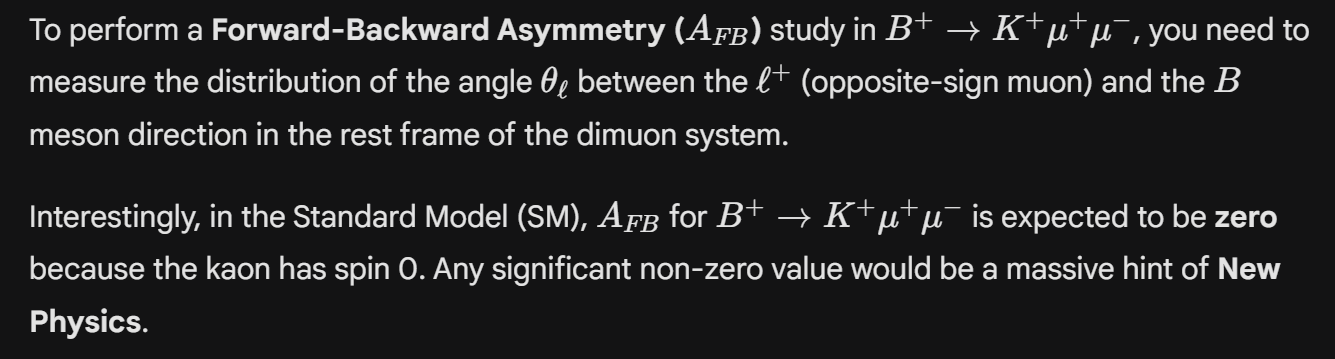

In [81]:
all_data.columns.tolist()

['B decay vertex x position',
 'B decay vertex y position',
 'B decay vertex z position',
 'B decay vertex fit chi2',
 'B impact parameter wrt primary vertex',
 'B impact parameter chi2 wrt primary vertex',
 'B flight distance wrt primary vertex',
 'B flight distance chi2 wrt primary vertex',
 'B cos(angle) between line-of-flight and momentum',
 'B magnitude of momentum',
 'B magnitude of momentum transverse to beam',
 'B 4-momentum energy component',
 'B 4-momentum x component',
 'B 4-momentum y component',
 'B 4-momentum z component',
 'B invariant mass',
 'B assumed particle type',
 'B lifetime',
 'Isolation: Charged cone angle',
 'Isolation: Charged cone number of particles contained',
 'Isolation: Charged cone eta difference between cone momentum and B',
 'Isolation: Charged cone phi difference between cone momentum and B',
 'Isolation: Charged cone ratio of B momentum and B+cone momentum all in transverse plane',
 'Isolation: Charged cone 4-momentum of max-PT object energy compon

In [147]:
def calculate_afb_angle_manual(df):
    # 1. Extract 4-momentum components
    # Dimuon system (The frame we want to boost to)
    E_dimu = df['dimuon-system 4-momentum energy component']
    px_dimu = df['dimuon-system 4-momentum x component']
    py_dimu = df['dimuon-system 4-momentum y component']
    pz_dimu = df['dimuon-system 4-momentum z component']
    M_dimu = df['dimuon-system invariant mass']

    # Opposite-sign muon (mu+)
    E_mu = df['Opposite-sign muon 4-momentum energy component']
    px_mu = df['Opposite-sign muon 4-momentum x component']
    py_mu = df['Opposite-sign muon 4-momentum y component']
    pz_mu = df['Opposite-sign muon 4-momentum z component']

    # B-meson (To define the direction in the RF)
    px_b = df['B 4-momentum x component']
    py_b = df['B 4-momentum y component']
    pz_b = df['B 4-momentum z component']

    # 2. Define the Boost Vector (beta = p / E)
    bx, by, bz = px_dimu/E_dimu, py_dimu/E_dimu, pz_dimu/E_dimu
    beta_sq = bx**2 + by**2 + bz**2
    gamma = 1.0 / np.sqrt(1.0 - beta_sq)

    # 3. Boost mu+ to the dimuon Rest Frame
    # Lorentz Transformation: E' = gamma(E - beta*p), p'_parallel = gamma(p_parallel - beta*E)
    b_dot_p_mu = bx*px_mu + by*py_mu + bz*pz_mu
    px_mu_rf = px_mu + (gamma - 1) * (b_dot_p_mu / beta_sq) * bx - gamma * bx * E_mu
    py_mu_rf = py_mu + (gamma - 1) * (b_dot_p_mu / beta_sq) * by - gamma * by * E_mu
    pz_mu_rf = pz_mu + (gamma - 1) * (b_dot_p_mu / beta_sq) * bz - gamma * bz * E_mu

    # 4. Boost B-meson to the dimuon Rest Frame
    b_dot_p_b = bx*px_b + by*py_b + bz*pz_b
    px_b_rf = px_b + (gamma - 1) * (b_dot_p_b / beta_sq) * bx - gamma * bx * df['B 4-momentum energy component']
    py_b_rf = py_b + (gamma - 1) * (b_dot_p_b / beta_sq) * by - gamma * by * df['B 4-momentum energy component']
    pz_b_rf = pz_b + (gamma - 1) * (b_dot_p_b / beta_sq) * bz - gamma * bz * df['B 4-momentum energy component']

    # 5. Calculate cos(theta)
    # Dot product of 3-vectors in the rest frame
    dot = px_mu_rf*px_b_rf + py_mu_rf*py_b_rf + pz_mu_rf*pz_b_rf
    mag_mu = np.sqrt(px_mu_rf**2 + py_mu_rf**2 + pz_mu_rf**2)
    mag_b = np.sqrt(px_b_rf**2 + py_b_rf**2 + pz_b_rf**2)

    return dot / (mag_mu * mag_b)

# Apply to your data
selected_data_no_dimuon['cos_theta_l'] = selected_data_no_dimuon.apply(calculate_afb_angle_manual, axis=1)

C:\Users\cissi\AppData\Local\Temp\ipykernel_19956\2506442456.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_data_no_dimuon['cos_theta_l'] = selected_data_no_dimuon.apply(calculate_afb_angle_manual, axis=1)


In [148]:
Jpsi_data['cos_theta_l'] = Jpsi_data.apply(calculate_afb_angle_manual, axis=1)

C:\Users\cissi\AppData\Local\Temp\ipykernel_19956\3198570862.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Jpsi_data['cos_theta_l'] = Jpsi_data.apply(calculate_afb_angle_manual, axis=1)


In [ ]:
norm_forward = Jpsi_data[Jpsi_data['cos_theta_l'] > 0]
norm_backward = Jpsi_data[Jpsi_data['cos_theta_l'] < 0]

res_norm_f, _, _, _, _, yield_norm_f, _ = perform_zfit(norm_forward, model_type='crystalball')
res_norm_b, _, _, _, _, yield_norm_b, _ = perform_zfit(norm_backward, model_type='crystalball')

N_f = yield_norm_f.value()
unc_f = res_norm_f.params[yield_norm_f]['hesse']['error']
N_b = yield_norm_b.value()@
unc_b = res_norm_b.params[yield_norm_b]['hesse']['error']

asymmetry_norm = (N_f - N_b) / (N_f + N_b)
unc_norm = 2 * np.sqrt( (N_b**2 * unc_f**2 + N_f**2 * unc_b**2) ) / (N_f + N_b)**2
print(f"Normalization Asymmetry: {asymmetry_norm:.6f} ± {unc_norm:.6f}")

valid: True
------------------------------
Model type: gauss
------------------------------
Number of B mesons: 412372.90540263057 ± 682.6611998123461
valid: True
------------------------------
Model type: gauss
------------------------------
Number of B mesons: 411161.770227132 ± 682.3478326196499
Normalization Asymmetry: 0.001471 ± 0.001172


In [150]:
selected_data_no_dimuon['q squared (GeV/c^2)^2'] = (selected_data_no_dimuon['dimuon-system invariant mass'] / 1000) ** 2

C:\Users\cissi\AppData\Local\Temp\ipykernel_19956\3667837205.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_data_no_dimuon['q squared (GeV/c^2)^2'] = (selected_data_no_dimuon['dimuon-system invariant mass'] / 1000) ** 2


In [166]:
forward = selected_data_no_dimuon[selected_data_no_dimuon['cos_theta_l'] > 0]
backward = selected_data_no_dimuon[selected_data_no_dimuon['cos_theta_l'] < 0]

res_fall, _, _, _, _, yield_fall, _ = perform_zfit(forward, model_type='crystalball')
res_ball, _, _, _, _, yield_ball, _ = perform_zfit(backward, model_type='crystalball')

N_fall = yield_fall.value()
err_fall = res_fall.params[yield_fall]['hesse']['error']
N_ball = yield_ball.value()
err_ball = res_ball.params[yield_ball]['hesse']['error']

# Calculate AFB
afb_all = (N_fall - N_ball) / (N_fall + N_ball) - asymmetry_norm

# Error propagation (Standard formula for asymmetry)
err_afb_all_raw = 2 * np.sqrt((N_ball**2 * err_fall**2 + N_fall**2 * err_ball**2) / (N_fall + N_ball)**4)

err_afb_all = np.sqrt(err_afb_all_raw**2 + unc_norm**2)

print(f"AFB (all data): {afb_all:.4f} +/- {err_afb_all:.4f}")

valid: True
------------------------------
Model type: crystalball
------------------------------
Number of B mesons: 1732.2593760639106 ± 66.66370052552867
valid: True
------------------------------
Model type: crystalball
------------------------------
Number of B mesons: 1625.3838877942628 ± 62.06768112974031
AFB (all data): 0.0304 +/- 0.0271


In [152]:
# N = 8
# edges = np.linspace(0.1, 20.0, N+1)
# intervals = list(zip(edges[:-1], edges[1:]))

# Region 1: 0.1 to J/psi_low (e.g., 3 bins = 4 edges)
edges_low = np.linspace(0.1, jpsi_q2_low, 5)

# Region 2: J/psi_high to psi2s_low (e.g., 2 bins = 3 edges)
edges_mid = np.linspace(jpsi_q2_high, psi2s_q2_low, 3)

# Region 3: psi2s_high to 22 (e.g., 3 bins = 4 edges)
edges_high = np.linspace(psi2s_q2_high, 22, 5)

# Create the list of intervals manually to ensure no 'zero-width' bins
intervals = []
for i in range(len(edges_low)-1):
    intervals.append((edges_low[i], edges_low[i+1]))
for i in range(len(edges_mid)-1):
    intervals.append((edges_mid[i], edges_mid[i+1]))
for i in range(len(edges_high)-1):
    intervals.append((edges_high[i], edges_high[i+1]))

afb_results = []
afb_errors = []
bin_centers_fb = []
xerr_fb = []

# Using the same intervals as your ACP study
for low, high in intervals:
    bin_df = selected_data_no_dimuon[(selected_data_no_dimuon['q squared (GeV/c^2)^2'] >= low) & 
                                     (selected_data_no_dimuon['q squared (GeV/c^2)^2'] < high)]
    
    # Split into Forward and Backward
    df_forward = bin_df[bin_df['cos_theta_l'] > 0]
    df_backward = bin_df[bin_df['cos_theta_l'] < 0]

    if len(df_forward) < 10 or len(df_backward) < 10:
        print(f"Skipping bin {low}-{high} due to low statistics.")
        continue
    
    # Perform fits (using your perform_zfit function)
    res_f, _, _, _, _, yield_f, _ = perform_zfit(df_forward, model_type='gauss')
    res_b, _, _, _, _, yield_b, _ = perform_zfit(df_backward, model_type='gauss')
    
    if res_f.valid and res_b.valid:
        N_f = yield_f.value()
        err_f = res_f.params[yield_f]['hesse']['error']
        N_b = yield_b.value()
        err_b = res_b.params[yield_b]['hesse']['error']
        
        # Calculate AFB
        afb = (N_f - N_b) / (N_f + N_b) - asymmetry_norm
        
        # Error propagation (Standard formula for asymmetry)
        err_afb_raw = 2 * np.sqrt((N_b**2 * err_f**2 + N_f**2 * err_b**2) / (N_f + N_b)**4)
        err_afb = np.sqrt(err_afb_raw**2 + unc_norm**2)
        
        afb_results.append(afb)
        afb_errors.append(err_afb)
        bin_centers_fb.append(0.5 * (low + high))
        xerr_fb.append(0.5 * (high - low))
        print(f"Bin {low}-{high}: AFB = {afb:.4f} +/- {err_afb:.4f}")

valid: False
------------------------------
Model type: gauss
------------------------------
Number of B mesons: 74.00124256226904 ± 2.2645754143880064
valid: True
------------------------------
Model type: gauss
------------------------------
Number of B mesons: 53.220575508842536 ± 8.615393301695912
valid: True
------------------------------
Model type: gauss
------------------------------
Number of B mesons: 132.42785403525056 ± 13.660372429108165
valid: True
------------------------------
Model type: gauss
------------------------------
Number of B mesons: 133.07279696943152 ± 12.360750738058476
Bin 2.3240089450093557-4.548017890018711: AFB = -0.0039 +/- 0.0694
valid: True
------------------------------
Model type: gauss
------------------------------
Number of B mesons: 228.6785605543996 ± 21.487820222534516
valid: True
------------------------------
Model type: gauss
------------------------------
Number of B mesons: 189.6794677775103 ± 17.658320764466076
Bin 4.548017890018711-6.

In [164]:
mean_afb = np.sum(np.array(afb_results) / np.array(afb_errors)**2) / np.sum(1 / np.array(afb_errors)**2)
mean_afb_err = np.sqrt(1 / np.sum(1 / np.array(afb_errors)**2))
mean_afb

np.float64(0.026664696870275697)

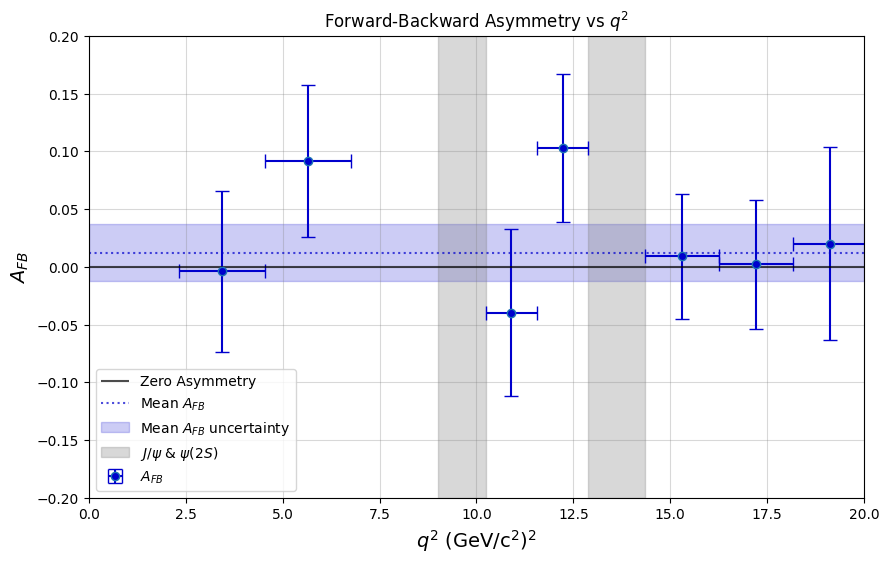

In [163]:
plt.style.use('default')
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.errorbar(bin_centers_fb, afb_results, xerr=xerr_fb, yerr=afb_errors, fmt='o', markerfacecolor=imperial_blue, ecolor=imperial_blue, capsize=5, label= '$A_{FB}$')
ax.hlines(0, xmin=0, xmax=20.0, colors='black', alpha = 0.7, label='Zero Asymmetry')
ax.hlines(afb_all, xmin=0, xmax=20.0, colors=imperial_blue, alpha = 0.7, linestyles=':', label='Mean $A_{FB}$')
ax.fill_between(
    np.linspace(0, 20.0, 200),
    afb_all - err_afb_all,
    afb_all + err_afb_all,
    color=imperial_blue,
    alpha=0.2,
    label='Mean $A_{FB}$ uncertainty'
)
ax.fill_betweenx([-0.20, 0.20], jpsi_q2_low, jpsi_q2_high, color='grey', alpha = 0.3, label='$J/\\psi$ & $\\psi(2S)$')
ax.fill_betweenx([-0.20, 0.20], psi2s_q2_low, psi2s_q2_high, color='grey', alpha = 0.3)
ax.legend(loc=3)
ax.set_xlabel('$q^{2}$ (GeV/c$^{2}$)$^{2}$', fontsize=14)
ax.set_ylabel('$A_{FB}$', fontsize=14)
ax.set_title('Forward-Backward Asymmetry vs $q^{2}$')
ax.set_xlim(0, 20.0)
ax.set_ylim(-0.2, 0.2)
ax.grid(color='gray', alpha=0.3)
fig.savefig('afb_vs_q2.png', transparent=True, bbox_inches='tight', dpi=300)

In [165]:
afb_all

<tf.Tensor: shape=(), dtype=float64, numpy=0.012268222763929046>